# Large BVAR — Chan (2020)

## Pre-statement

This notebook implements the **seven large Bayesian VARs** in Chan (2020) through one compact project structure:
The starting point is the most elaborate model, **BVAR-CSV-t-MA**. Its error-dynamics branch is nested:

$$
\text{BVAR-CSV-t-MA}
\xrightarrow{\text{MA off}}
\text{BVAR-CSV-t}
\xrightarrow{\text{t off}}
\text{BVAR-CSV}
\xrightarrow{\text{SV off}}
\text{BVAR-NCP}.
$$

Minnesota, independent prior (IP), and SSVS are **different prior/covariance branches**. They live in the same engine, but they are not obtained by setting $\psi$, $\lambda_t$, or $h_t$ to special values.


## Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bvar_model_function import (
    CORE_LABELS,
    CORE_VARIABLES,
    FULL_VARIABLE_LABELS,
    MODEL_PRESETS,
    aggregate_forecast_draws,
    bvar_mcmc_diagnostics,
    compare_result_tables,
    coefficient_posterior_table,
    data_source_table,
    fit_bvar,
    forecast_error_variance_decomposition,
    forecast_origin_from_fit,
    forecast_paths_from_fit,
    get_model_config,
    historical_decomposition,
    impulse_responses,
    load_chan_data,
    model_presets_table,
    nested_ncp_configs,
    prepare_large_bvar_sample,
    prior_minnesota,
    prior_natural_conjugate,
    result_tables,
    run_large_bvar,
    sign_restriction_draws,
    sign_identification_diagnostics,
)

from bvar_plot_function import (
    active_mcmc_parameters,
    plot_alpl,
    plot_coefficient_marginals,
    plot_coefficient_traces,
    plot_fevd,
    plot_forecast_errors,
    plot_forecast_fan,
    plot_forecasts,
    plot_historical_decomposition,
    plot_irf_grid,
    plot_mcmc_marginals,
    plot_mcmc_diagnostic_acf,
    plot_mcmc_diagnostic_traces,
    plot_mcmc_traces,
    plot_model_comparison,
    plot_model_series,
    plot_rmsfe,
    plot_sign_restriction_diagnostics,
    plot_sign_identification,
    plot_sigma_diagonal,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)


## 1. seven models same framework

Chan's comparison contains four prior/covariance families plus three increasingly rich error-dynamics extensions of the natural-conjugate prior.

In [2]:
display(model_presets_table())

,model,prior,CSV,Student-t,MA(1),c1,c2,c3
0,BVAR-Minn,minnesota,False,False,False,0.04,0.01,100.0
1,BVAR-NCP,ncp,False,False,False,0.04,100.00,NaN
2,BVAR-IP,ip,False,False,False,0.04,0.01,100.0
3,BVAR-SSVS,ssvs,False,False,False,0.04,0.01,100.0
4,BVAR-CSV,ncp,True,False,False,0.04,100.00,NaN
5,BVAR-CSV-t,ncp,True,True,False,0.04,100.00,NaN
6,BVAR-CSV-t-MA,ncp,True,True,True,0.04,100.00,NaN


The critical nesting is the last four rows:

| model | common stochastic volatility | Student-t | MA(1) |
|---|---:|---:|---:|
| BVAR-NCP | off | off | off |
| BVAR-CSV | on | off | off |
| BVAR-CSV-t | on | on | off |
| BVAR-CSV-t-MA | on | on | on |


In [3]:
for name, cfg in nested_ncp_configs().items():
    print(
        f"{name:15s}  prior={cfg.prior:9s}  "
        f"SV={cfg.stochastic_volatility!s:5s}  "
        f"t={cfg.student_t!s:5s}  MA={cfg.ma1!s:5s}"
    )

BVAR-NCP         prior=ncp        SV=False  t=False  MA=False
BVAR-CSV         prior=ncp        SV=True   t=False  MA=False
BVAR-CSV-t       prior=ncp        SV=True   t=True   MA=False
BVAR-CSV-t-MA    prior=ncp        SV=True   t=True   MA=True 


## 2. Models 
The reduced-form VAR is

$$
y_t = c + B_1y_{t-1} + \cdots + B_py_{t-p} + u_t.
$$

For **BVAR-CSV-t-MA**, the reduced-form residual is represented as

$$
u_t = e_t + \psi e_{t-1},
$$

with

$$
e_t \mid h_t,\lambda_t,\Sigma
\sim
N\!\left(0,\lambda_t e^{h_t}\Sigma\right),
$$

and

$$
h_t = \rho h_{t-1} + \eta_t,
\qquad
\eta_t\sim N(0,\sigma_h^2).
$$

The Student-t innovation is generated through the scale mixture

$$
\lambda_t \sim IG\left(\frac{\nu}{2},\frac{\nu}{2}\right).
$$

So the three switches have literal meanings inside the generalized engine:

- `ma1=False` fixes $\psi=0$ and skips its MH update;
- `student_t=False` fixes $\lambda_t=1$, deactivates $\nu$, and uses Gaussian predictive densities;
- `stochastic_volatility=False` fixes $h_t=0$ and deactivates $\rho$ and $\sigma_h^2$.

## 3. Parameters

In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "chan_2020"

# Chan's main forecasting settings
p = 4
T0 = 41
T = 208
NSIMS = 5000
BURNIN = 100
SEED = 0

# Posterior forecast / structural horizons
FAN_HORIZON = 12
STRUCTURAL_HORIZON = 12
STRUCTURAL_MAX_DRAWS = 250
STRUCTURAL_SEED = 42

# The same sign identification is used for every model so that the structural
# results are comparable across specifications. These signs are a notebook
# configuration, not restrictions supplied by Chan's forecasting code.
SIGN_SHOCK_VAR = "Federal funds rate"
SIGN_SHOCK_NAME = "monetary policy"
SIGN_RESTRICTIONS = {
    "Federal funds rate": +1,
    "Real GDP": -1,
    "PCE": -1,
}
SIGN_HORIZON = 1
SIGN_MAX_TRIES = 2000

# Sign-identification strength diagnosis. 
SIGN_DIAG_ROTATIONS = 30
SIGN_DIAG_MAX_DRAWS = 120
SIGN_DIAG_MAX_TRIES = 2000

# MCMC mixing / Monte Carlo precision diagnostics for Gibbs/MH models.
MCMC_DIAG_MAX_LAG = 40

STRUCTURAL_RESPONSE_VARS = [
    "Real GDP",
    "Industrial production",
    "Unemployment rate",
    "PCE",
    "Federal funds rate",
    "S&P 500",
]
STRUCTURAL_RESPONSE_INDICES = [
    FULL_VARIABLE_LABELS.index(name)
    for name in STRUCTURAL_RESPONSE_VARS
]

RUN_FULL_REPLICATION = False
MODEL_NAMES = list(MODEL_PRESETS)


MODEL_NAME = "BVAR-CSV-t-MA"
config = get_model_config(MODEL_NAME, p=p)

fits = {}
results = {}

config


BVARConfig(name='BVAR-CSV-t-MA', prior='ncp', stochastic_volatility=True, student_t=True, ma1=True, p=4, c1=0.04000000000000001, c2=100.0, c3=100.0, q=0.5, kappa1=10.0, rho0=0.9, Vrho=0.04000000000000001, nuh0=5.0, Sh0=0.04, rho_init=0.8, sigh2_init=0.1, nu_init=5.0, nu_upper=50.0, psi0=0.0, Vpsi=1.0, psi_init=0.1, psi_bound=0.99, psi_hessian_every=100)

The preset above is equivalent to constructing a configuration with

```python
prior="ncp"
stochastic_volatility=True
student_t=True
ma1=True
```

But using the named presets is safer because it also applies the correct prior hyperparameters from `main_forecasting.m`.

## 4. Chan data contract

In [5]:
display(data_source_table())

,variable,label,file,range,source,transform,data structure
0,1,Real GDP,ROUTPUTQvQd.xlsx,AI70:HA283,rt,400*dlog,Q vintage / Q observations
1,2,Real consumption,RCONQvQd.xlsx,AI70:HA283,rt,400*dlog,Q vintage / Q observations
2,3,Business fixed investment,rinvbfQvQd.xlsx,AI70:HA283,rt,400*dlog,Q vintage / Q observations
3,4,Residential investment,rinvresidQvQd.xlsx,AI70:HA283,rt,400*dlog,Q vintage / Q observations
4,5,Net exports,RNXQvQd.xlsx,AI71:HA283,rt,level,Q vintage / Q observations
5,6,Nonfarm payrolls / income proxy,npiQvQd.xlsx,AI70:HA283,rt,400*dlog,Q vintage / Q observations
6,7,Industrial production,iptMvMd.xlsx,EF542:YI1184,rt,400*dlog,M vintage / M observations
7,8,Unemployment rate,rucQvMd.xlsx,AI209:HA848,rt,level,Q vintage / M observations
8,9,Employment,employMvMd.xlsx,DG302:XJ944,rt,400*dlog,M vintage / M observations
9,10,Hours,hMvMd.xlsx,AD206:UG848,rt,400*dlog,M vintage / M observations


In [6]:
rt_data, nonrev_data, tcode, var_type = load_chan_data(DATA_DIR)

print(f"real-time vintage series : {len(rt_data)}")
print(f"non-revised series       : {len(nonrev_data)}")
print(f"number of BVAR variables : {len(var_type)}")

real-time vintage series : 13
non-revised series       : 7
number of BVAR variables : 20


## 5. Inspect one recursive origin before running the full exercise

In [7]:
sample = prepare_large_bvar_sample(
    rt_data,
    nonrev_data,
    tcode,
    var_type,
    t=T,
    T0=T0,
    p=p,
)

print("recursive origin       :", sample["t"])
print("complete observations  :", sample["data"].shape[0])
print("estimation observations:", sample["shortYt"].shape[0])
print("number of variables    :", sample["shortYt"].shape[1])
print("latest row incomplete  :", sample["is_last_miss"])
print("regressors / equation  :", 1 + p * sample["shortYt"].shape[1])
print("VAR coefficients       :", (1 + p * sample["shortYt"].shape[1]) * sample["shortYt"].shape[1])

recursive origin       : 208
complete observations  : 206
estimation observations: 202
number of variables    : 20
latest row incomplete  : False
regressors / equation  : 81
VAR coefficients       : 1620


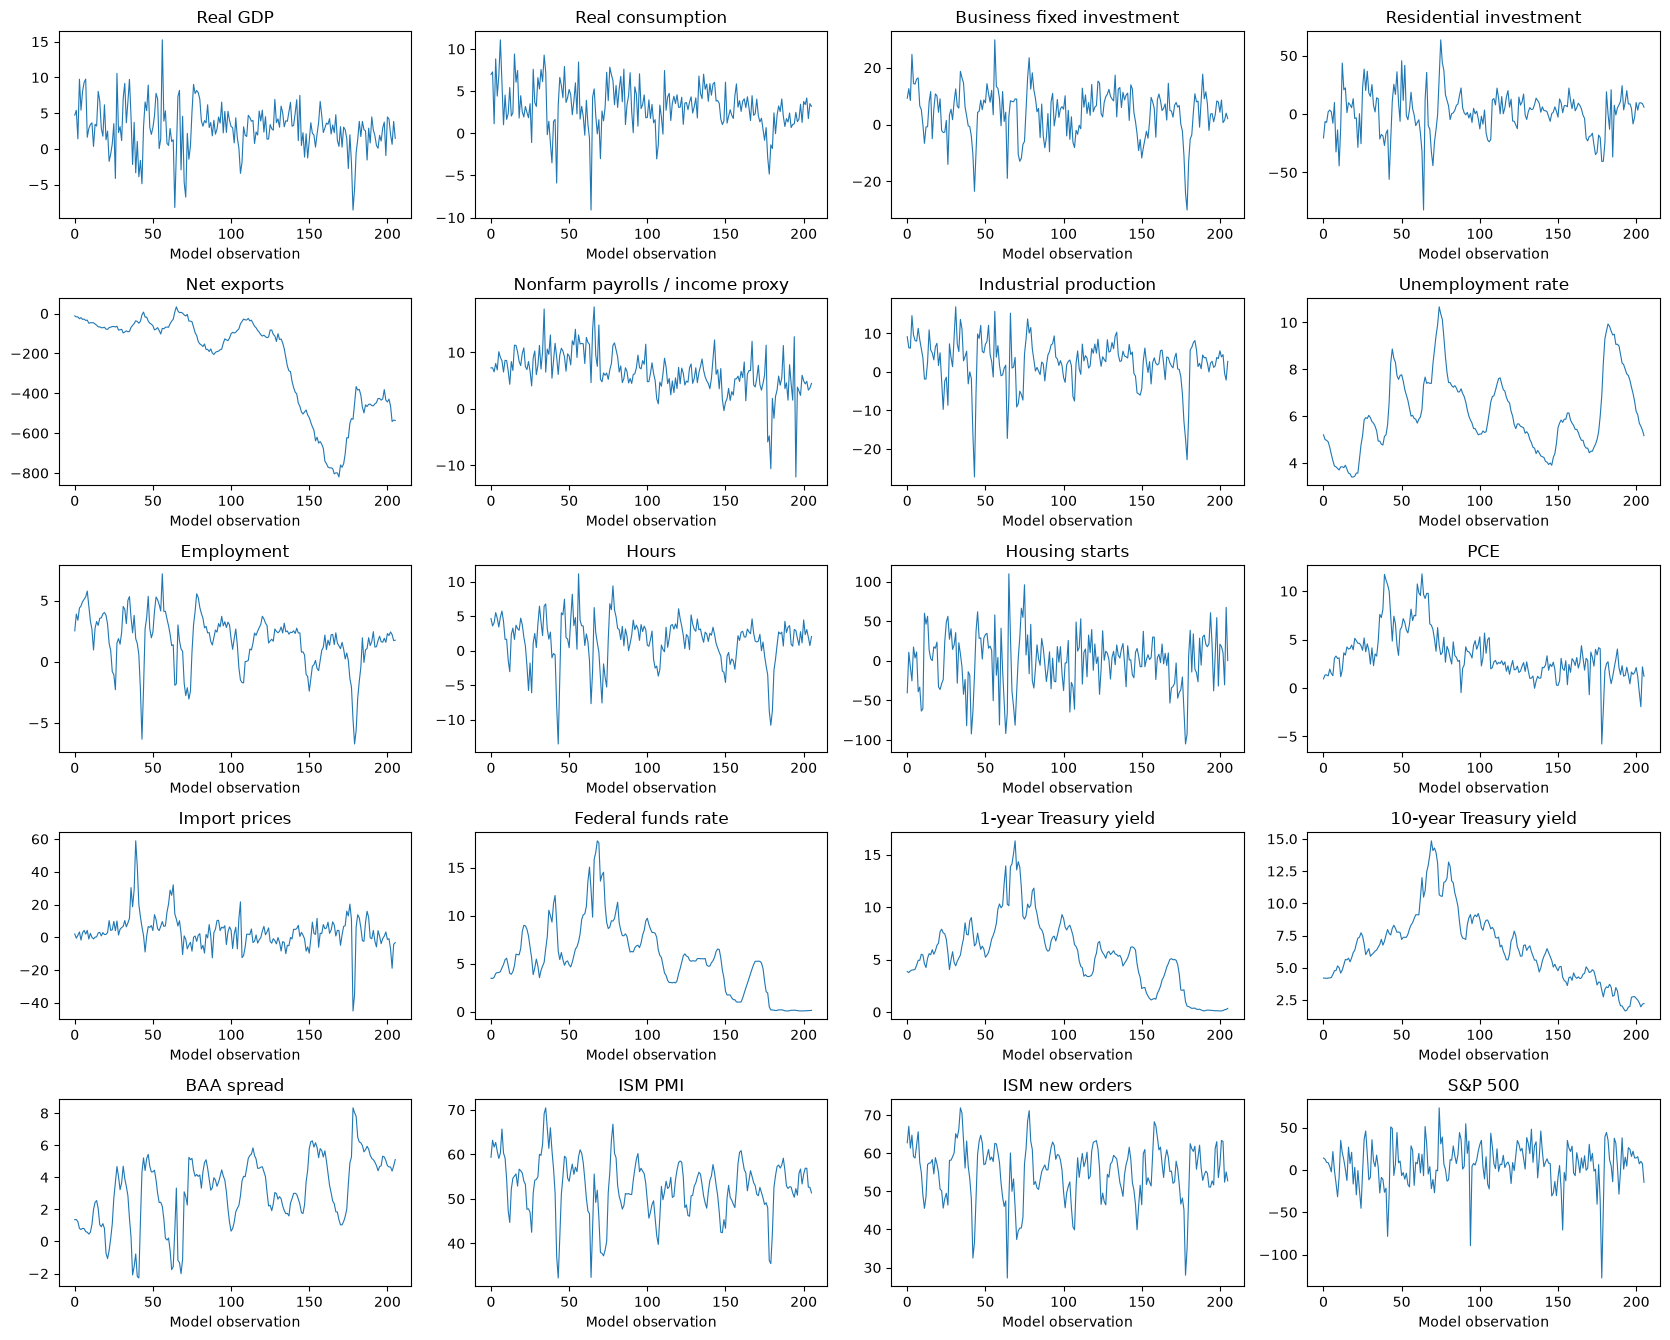

In [8]:
plot_model_series(sample);

# Model 1 — BVAR-Minn

## Specification, prior and algorithm

The model is the 20-variable VAR(4)

$$
y_t = c + B_1y_{t-1}+\cdots+B_4y_{t-4}+u_t,
\qquad
u_t\sim N(0,\Sigma).
$$

Here $\Sigma$ is **fixed and diagonal**, using the univariate AR residual variances constructed by `prior_Minn.m`. The coefficient prior is Minnesota: all prior means are zero; own lags receive variance $c_1/\ell^2$; cross lags receive $c_2\sigma_i^2/(\ell^2\sigma_j^2)$; and the intercept variance is $c_3$.

Because $\Sigma$ is fixed, there is no covariance Gibbs block. Each posterior iteration only draws the complete coefficient matrix $A$ from its Gaussian posterior and then uses that draw for forecasting. There are no latent CSV, Student-t, MA or SSVS states.

In [9]:
config_minn = get_model_config("BVAR-Minn", p=p)

if config_minn.prior == "ncp":
    prior_minn = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_minn.c1, c2=config_minn.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_minn["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_minn["nu0"])
    print("VA0 shape =", prior_minn["VA0"].shape)
else:
    prior_minn = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_minn.c1, c2=config_minn.c2, c3=config_minn.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_minn["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_minn["variance"].shape)

config_minn

,AR residual variance
Real GDP,9.253407
Real consumption,5.730322
Business fixed investment,44.098745
Residential investment,248.621489
Net exports,437.428110
Nonfarm payrolls / income proxy,10.471118
Industrial production,22.430850
Unemployment rate,0.058817
Employment,1.332456
Hours,6.302005


Minnesota coefficient variances: (1620,)


BVARConfig(name='BVAR-Minn', prior='minnesota', stochastic_volatility=False, student_t=False, ma1=False, p=4, c1=0.04000000000000001, c2=0.010000000000000002, c3=100.0, q=0.5, kappa1=10.0, rho0=0.9, Vrho=0.04000000000000001, nuh0=5.0, Sh0=0.04, rho_init=0.8, sigh2_init=0.1, nu_init=5.0, nu_upper=50.0, psi0=0.0, Vpsi=1.0, psi_init=0.1, psi_bound=0.99, psi_hessian_every=100)

### Estimation and posterior diagnostics

In [10]:
fit_minn = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_minn,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-Minn"] = fit_minn

print(fit_minn["model_name"])
print(f"fitted equations        : {fit_minn['n']}")
print(f"coefficients / equation : {fit_minn['k']}")
print(f"total VAR coefficients  : {fit_minn['n'] * fit_minn['k']}")

if not fit_minn["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_minn["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_minn = fit_minn["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_minn.round(4))

print("MH / accept-reject acceptance shares:")
if fit_minn["acceptance"]:
    display(pd.Series(fit_minn["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

BVAR-Minn
fitted equations        : 20
coefficients / equation : 81
total VAR coefficients  : 1620
No additional scalar latent state is sampled in this specification.
Posterior mean of every coefficient — 81 regressors x 20 equations


equation,1-year Treasury yield,10-year Treasury yield,BAA spread,Business fixed investment,Employment,Federal funds rate,Hours,Housing starts,ISM PMI,ISM new orders,Import prices,Industrial production,Net exports,Nonfarm payrolls / income proxy,PCE,Real GDP,Real consumption,Residential investment,S&P 500,Unemployment rate
coefficient,,,,,,,,,,,,,,,,,,,,
1-year Treasury yield L1,0.7192,0.0430,-0.1735,0.1023,0.0590,0.2379,0.0475,-2.9104,-0.2040,-0.4114,-0.2371,0.1384,1.6032,0.1014,0.0560,-0.0191,0.0084,-1.5272,1.0869,0.0059
1-year Treasury yield L2,-0.0441,-0.0091,0.0143,0.0211,0.0261,-0.0338,-0.0051,3.2307,0.1005,0.1321,0.1829,0.1249,0.5698,0.0907,0.0309,0.0356,0.1310,0.8809,1.4769,-0.0036
1-year Treasury yield L3,0.1000,0.0128,-0.0336,0.0150,0.0257,0.0344,0.0527,0.5716,0.0794,0.0868,0.1315,0.1040,0.3669,0.0707,0.0168,0.0925,0.0691,0.3662,0.4873,-0.0027
1-year Treasury yield L4,-0.0083,0.0014,-0.0011,-0.0805,0.0004,0.0029,-0.0013,0.0656,0.0057,-0.0073,-0.0054,-0.0042,0.0951,-0.0154,0.0060,0.0158,0.0247,0.1691,-0.2483,0.0009
10-year Treasury yield L1,0.1537,0.8640,0.1646,0.6492,-0.0460,0.1007,0.0563,-3.8549,-0.1921,-0.0234,-0.9603,0.0297,-1.9135,-0.0783,-0.1044,0.0781,-0.1595,-2.3145,-3.6325,0.0049
10-year Treasury yield L2,-0.0470,-0.0514,0.0615,-0.1554,-0.0093,-0.0750,-0.0352,3.8612,-0.0158,0.0281,-0.0759,-0.0133,-0.4273,0.0746,-0.0303,0.0021,0.1411,1.4693,1.0689,-0.0050
10-year Treasury yield L3,0.0092,0.0202,-0.0311,-0.0616,0.0265,0.0323,0.0883,0.6166,0.0473,0.0763,0.1342,0.0292,-0.0422,0.0251,-0.0015,0.0781,0.0729,0.9399,0.9163,-0.0066
10-year Treasury yield L4,-0.0195,-0.0345,-0.0030,-0.1914,-0.0102,-0.0035,-0.0141,-0.2273,-0.0579,-0.0435,0.0740,-0.1261,0.1646,-0.0869,0.0014,-0.0006,0.0100,0.4433,0.0081,0.0024
BAA spread L1,-0.0108,0.0308,0.6676,-0.6073,-0.0501,-0.0668,-0.1618,0.7903,0.1222,0.2685,-0.6258,-0.2470,0.4588,-0.2517,-0.1100,-0.0162,0.1412,0.8020,-0.1617,0.0199


MH / accept-reject acceptance shares:
No MH / acceptance-rejection block in this specification.


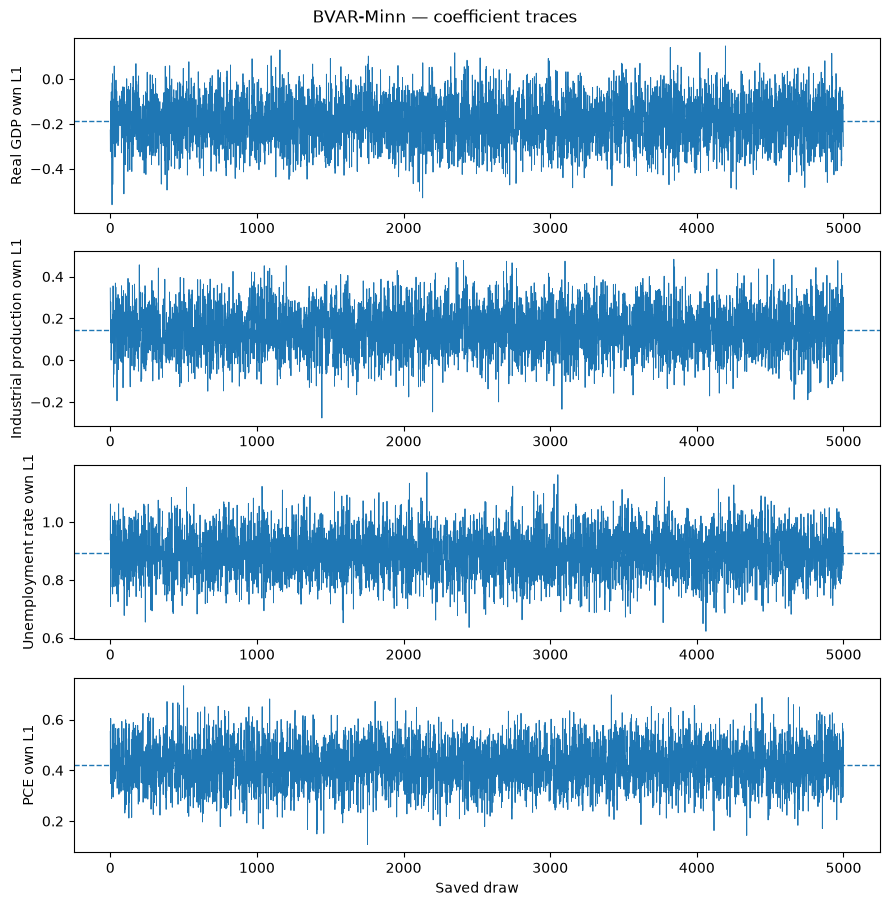

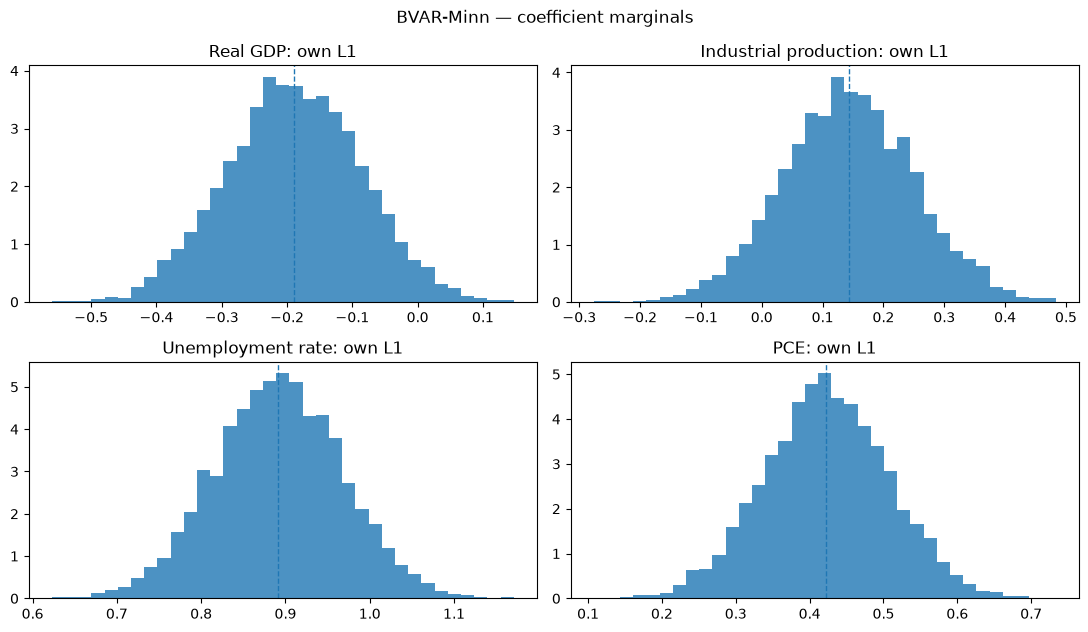

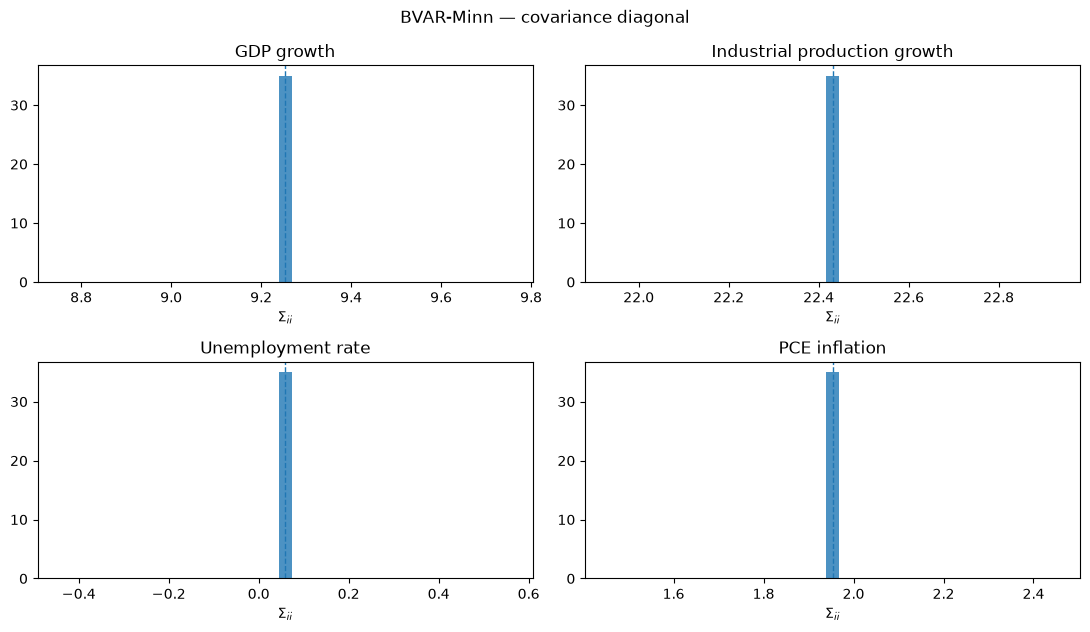

In [11]:
if active_mcmc_parameters(fit_minn):
    plot_mcmc_traces(fit_minn);
    plot_mcmc_marginals(fit_minn);
else:
    plot_coefficient_traces(fit_minn);
    plot_coefficient_marginals(fit_minn);

plot_sigma_diagonal(fit_minn);

### Results — one-origin predictive distribution and fan forecast

,actual,posterior mean forecast,log predictive likelihood
Real GDP,0.4837,2.8543,-2.3492
Real consumption,2.6345,2.7997,-1.8292
Business fixed investment,-5.1971,3.2135,-3.5954
Residential investment,7.0848,4.2003,-3.7239
Net exports,-571.5000,-543.4294,-4.8315
Nonfarm payrolls / income proxy,3.6618,3.0341,-2.1451
Industrial production,-3.7210,1.8139,-3.1455
Unemployment rate,5.0000,5.1406,0.3055
Employment,1.9679,1.5240,-1.1668
Hours,2.6316,1.2861,-2.0087


joint log predictive likelihood: -45.8594


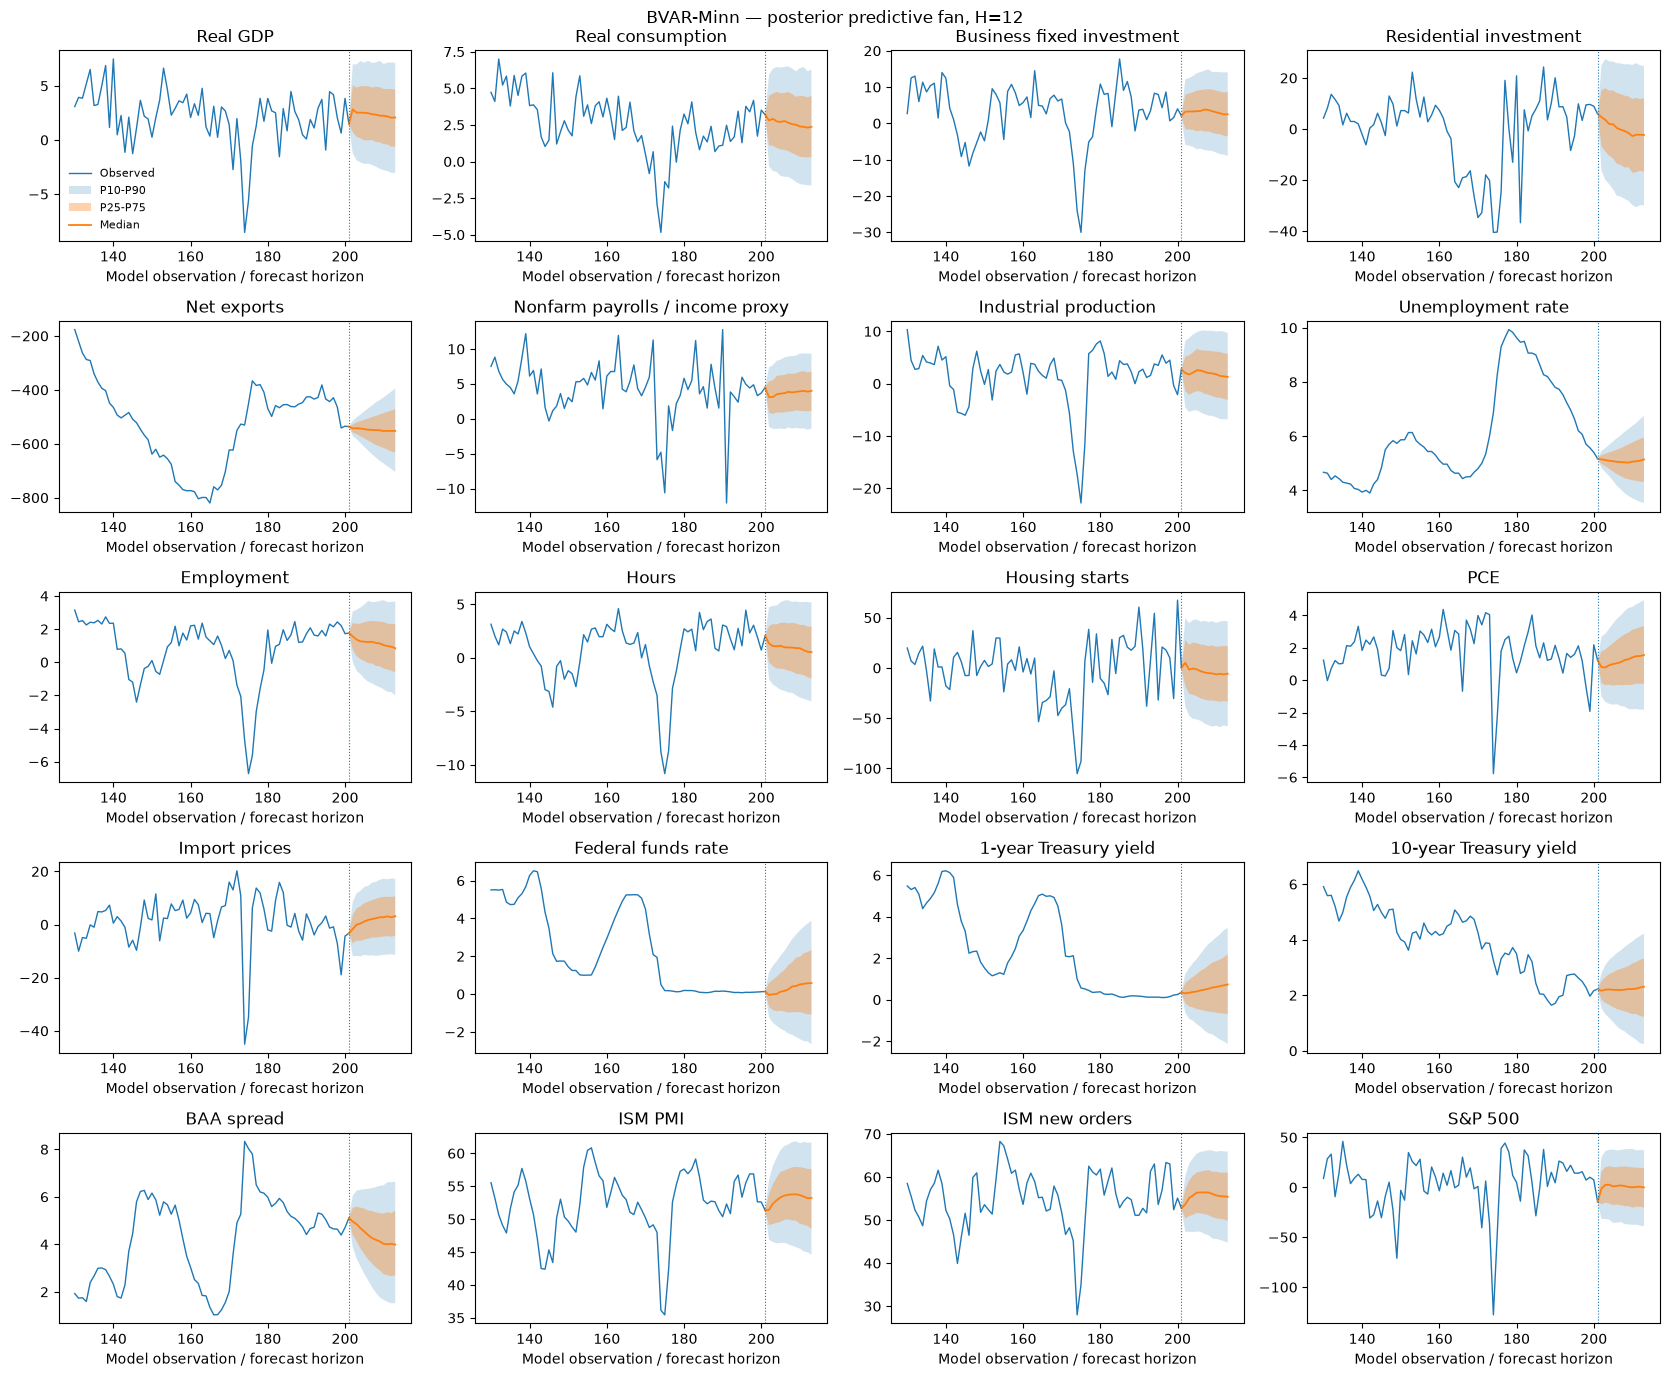

In [12]:
tmp0_minn, tmp1_minn = forecast_origin_from_fit(
    fit_minn,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_minn, lpl0_minn = aggregate_forecast_draws(tmp0_minn, n=len(FULL_VARIABLE_LABELS))

origin_table_minn = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_minn,
        "log predictive likelihood": lpl0_minn[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_minn.round(4))
print("joint log predictive likelihood:", round(float(lpl0_minn[-1]), 4))

fan_minn = forecast_paths_from_fit(
    fit_minn,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_minn);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

,median acceptance a_d,median A90 (deg),median R_d,median vMF kappa,draws measured
restriction set,,,,,
monetary policy,0.265,79.682,0.353,8.014,91


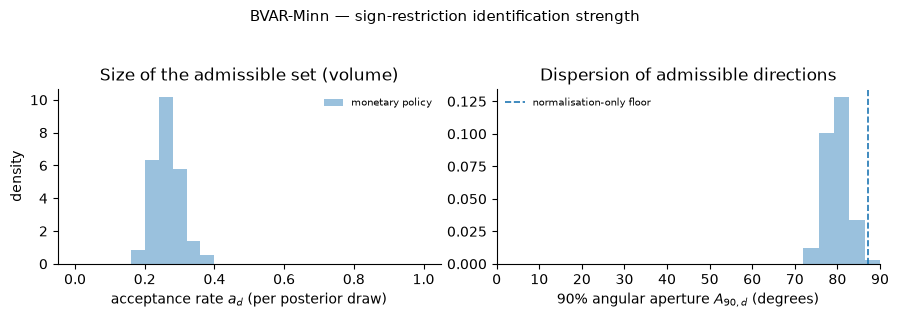

In [13]:
sign_strength_minn = sign_identification_diagnostics(
    fit_minn,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_minn = plot_sign_identification(
    sign_strength_minn,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_minn)
plt.show()


searched posterior draws         250.000000
accepted draws                   164.000000
mean QR tries                      1.000000
median QR tries                    1.000000
flip share                         0.481707
unstable share among searched      0.344000
Name: sign restriction diagnostics, dtype: float64

FEVD normalization: base Sigma; common CSV/t scale excluded from horizon weighting
HD max reconstruction error: 1.198e-11


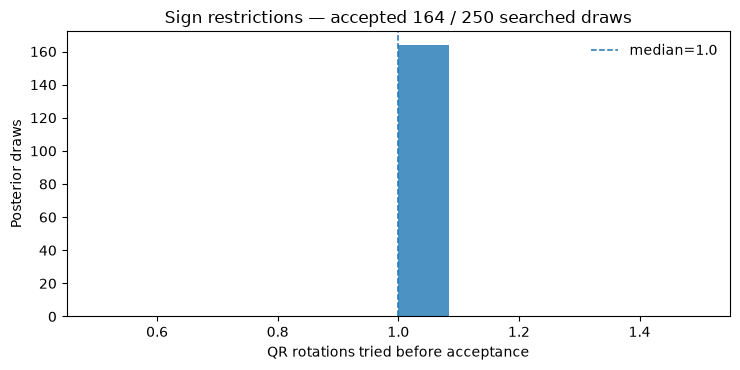

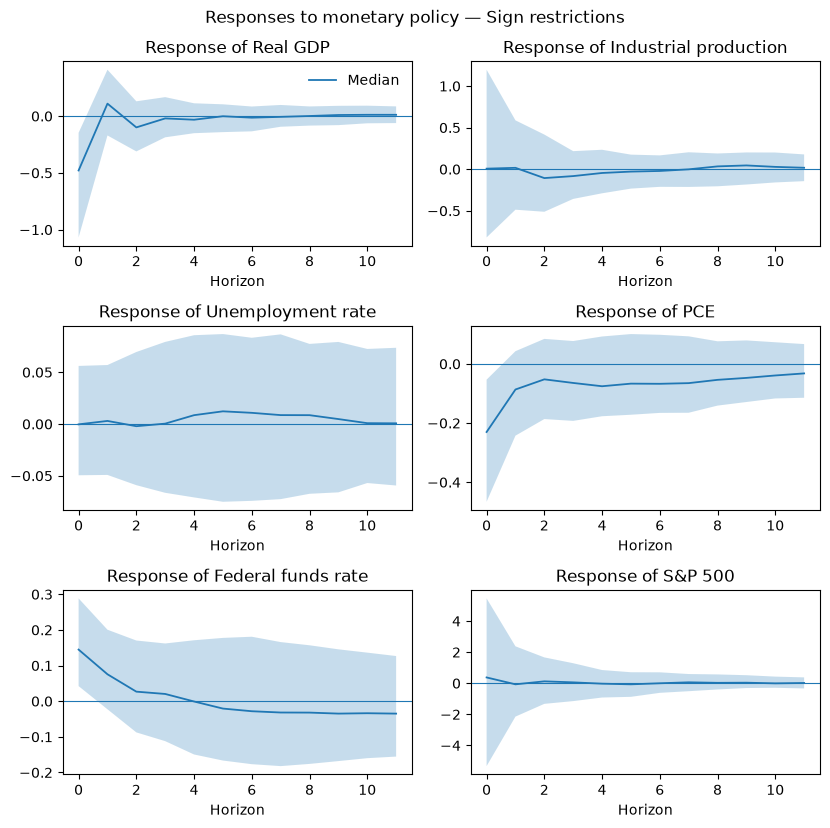

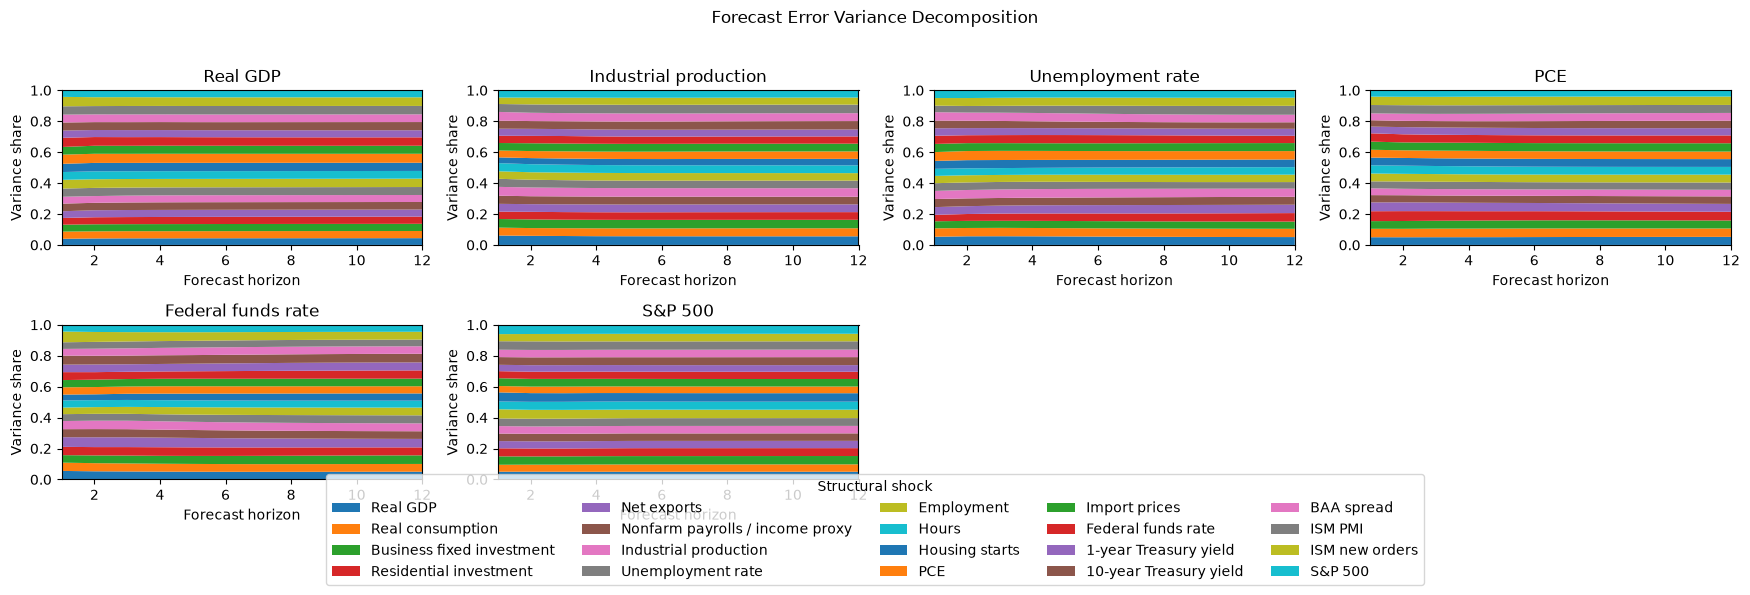

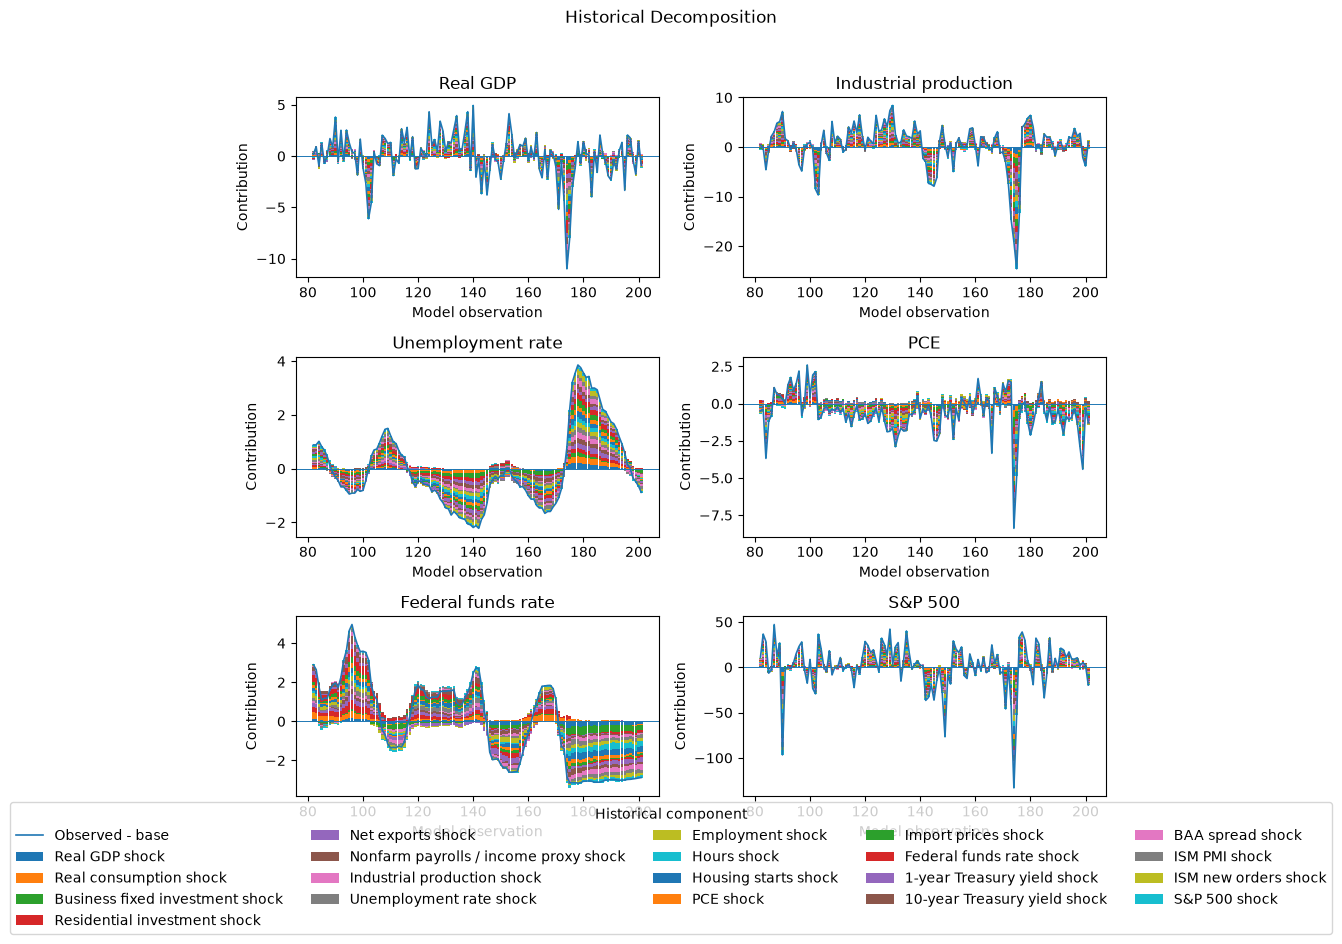

In [14]:
A0_minn, sign_info_minn = sign_restriction_draws(
    fit_minn,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_minn["n_candidates"],
    "accepted draws": sign_info_minn["n_used"],
    "mean QR tries": sign_info_minn["mean_tries"],
    "median QR tries": sign_info_minn["median_tries"],
    "flip share": sign_info_minn["flip_share"],
    "unstable share among searched": sign_info_minn["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_minn);

irf_minn, irf_info_minn = impulse_responses(
    fit_minn,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_minn,
    A0_draw_indices=sign_info_minn["used_draw_indices"],
)
plot_irf_grid(
    irf_minn,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_minn, fevd_info_minn = forecast_error_variance_decomposition(
    fit_minn,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_minn,
    A0_draw_indices=sign_info_minn["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_minn["normalization"])
plot_fevd(
    fevd_minn,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_minn, hd_info_minn = historical_decomposition(
    fit_minn,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_minn,
    A0_draw_indices=sign_info_minn["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_minn['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_minn,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_minn

# Model 2 — BVAR-NCP

## Specification, prior and algorithm

BVAR-NCP keeps the same 20-variable VAR(4), but replaces the Minnesota/fixed-covariance specification with Chan's **natural-conjugate matrix-normal inverse-Wishart prior**:

$$
A\mid\Sigma \sim MN(A_0,V_A,\Sigma),
\qquad
\Sigma\sim IW(\nu_0,S_0).
$$

`prior_NC.m` sets $A_0=0$, scales lag shrinkage by univariate AR residual variances, uses $S_0=\operatorname{diag}(\hat\sigma_i^2)$, and sets $\nu_0=n+3$.

At every retained draw the algorithm:

1. draws $\Sigma$ from its inverse-Wishart posterior;
2. draws the full $A$ matrix from the corresponding matrix-normal posterior;
3. simulates the predictive distribution.

No CSV, Student-t or MA state is active.

In [15]:
config_ncp = get_model_config("BVAR-NCP", p=p)

if config_ncp.prior == "ncp":
    prior_ncp = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_ncp.c1, c2=config_ncp.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_ncp["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_ncp["nu0"])
    print("VA0 shape =", prior_ncp["VA0"].shape)
else:
    prior_ncp = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_ncp.c1, c2=config_ncp.c2, c3=config_ncp.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_ncp["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_ncp["variance"].shape)

config_ncp

,AR residual variance
Real GDP,9.253407
Real consumption,5.730322
Business fixed investment,44.098745
Residential investment,248.621489
Net exports,437.428110
Nonfarm payrolls / income proxy,10.471118
Industrial production,22.430850
Unemployment rate,0.058817
Employment,1.332456
Hours,6.302005


nu0 = 23
VA0 shape = (81,)


BVARConfig(name='BVAR-NCP', prior='ncp', stochastic_volatility=False, student_t=False, ma1=False, p=4, c1=0.04000000000000001, c2=100.0, c3=100.0, q=0.5, kappa1=10.0, rho0=0.9, Vrho=0.04000000000000001, nuh0=5.0, Sh0=0.04, rho_init=0.8, sigh2_init=0.1, nu_init=5.0, nu_upper=50.0, psi0=0.0, Vpsi=1.0, psi_init=0.1, psi_bound=0.99, psi_hessian_every=100)

### Estimation and posterior diagnostics

In [16]:
fit_ncp = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_ncp,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-NCP"] = fit_ncp

print(fit_ncp["model_name"])
print(f"fitted equations        : {fit_ncp['n']}")
print(f"coefficients / equation : {fit_ncp['k']}")
print(f"total VAR coefficients  : {fit_ncp['n'] * fit_ncp['k']}")

if not fit_ncp["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_ncp["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_ncp = fit_ncp["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_ncp.round(4))

print("MH / accept-reject acceptance shares:")
if fit_ncp["acceptance"]:
    display(pd.Series(fit_ncp["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

BVAR-NCP
fitted equations        : 20
coefficients / equation : 81
total VAR coefficients  : 1620
No additional scalar latent state is sampled in this specification.
Posterior mean of every coefficient — 81 regressors x 20 equations


equation,1-year Treasury yield,10-year Treasury yield,BAA spread,Business fixed investment,Employment,Federal funds rate,Hours,Housing starts,ISM PMI,ISM new orders,Import prices,Industrial production,Net exports,Nonfarm payrolls / income proxy,PCE,Real GDP,Real consumption,Residential investment,S&P 500,Unemployment rate
coefficient,,,,,,,,,,,,,,,,,,,,
1-year Treasury yield L1,0.5833,0.0599,-0.3435,-0.1173,0.1053,0.4198,0.0010,-4.7981,-0.4353,-0.9595,-0.6883,0.1987,2.9363,0.0308,0.0334,-0.1693,0.1253,-2.1057,3.0356,0.0223
1-year Treasury yield L2,-0.0187,-0.0455,0.0553,0.1853,0.0788,-0.1052,0.0285,6.9361,0.2105,0.2333,0.6294,0.3788,1.5650,0.2072,0.0999,0.1353,0.2500,1.7377,2.3972,-0.0079
1-year Treasury yield L3,0.0884,0.0257,-0.0874,0.1590,0.0417,0.0980,0.1089,0.6485,0.1462,0.1062,0.4377,0.2793,1.1428,0.1497,0.0599,0.2280,0.0997,0.2739,1.1465,-0.0028
1-year Treasury yield L4,-0.0049,-0.0025,0.0043,-0.1239,-0.0109,0.0036,-0.0226,-0.0504,-0.0083,-0.0795,0.0774,-0.0019,0.2867,-0.0145,0.0099,0.0075,0.0552,0.2714,-0.7788,0.0049
10-year Treasury yield L1,0.2839,0.7796,0.3856,1.6201,-0.0247,0.0916,0.2548,-4.9164,-0.1145,0.6427,-1.8154,0.2129,-3.5443,-0.0953,-0.1271,0.3118,-0.3057,-3.2237,-6.4965,-0.0164
10-year Treasury yield L2,-0.1525,-0.0428,0.1284,-0.3229,-0.0149,-0.1972,-0.0896,8.1668,-0.1002,0.0039,-0.2610,-0.0588,-0.7277,0.1975,-0.0697,-0.0760,0.1941,2.0992,1.8326,-0.0082
10-year Treasury yield L3,0.0425,0.0105,-0.1014,-0.0904,0.0587,0.0965,0.1990,0.1474,0.0594,0.0969,0.2887,0.0524,-0.0780,0.0510,0.0028,0.1189,0.0637,1.2080,2.3644,-0.0147
10-year Treasury yield L4,-0.0566,-0.0386,-0.0127,-0.5062,-0.0418,-0.0084,-0.0732,-1.8170,-0.2089,-0.2334,0.2393,-0.3814,0.5361,-0.2079,-0.0175,-0.0789,-0.0233,0.4857,-0.2750,0.0121
BAA spread L1,-0.0042,0.0925,0.4971,-1.1862,-0.1371,-0.1088,-0.3869,-2.2776,0.0612,0.0411,-0.3630,-0.6582,0.7684,-0.4578,-0.1300,-0.2349,0.0549,0.2079,-1.2444,0.0431


MH / accept-reject acceptance shares:
No MH / acceptance-rejection block in this specification.


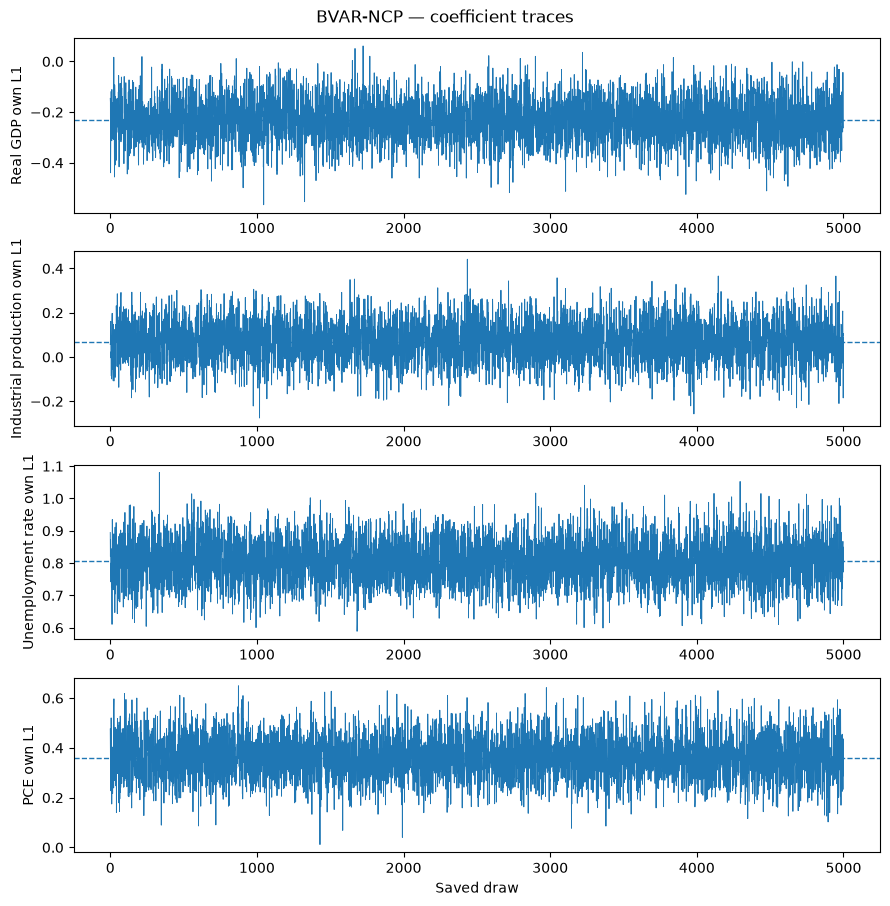

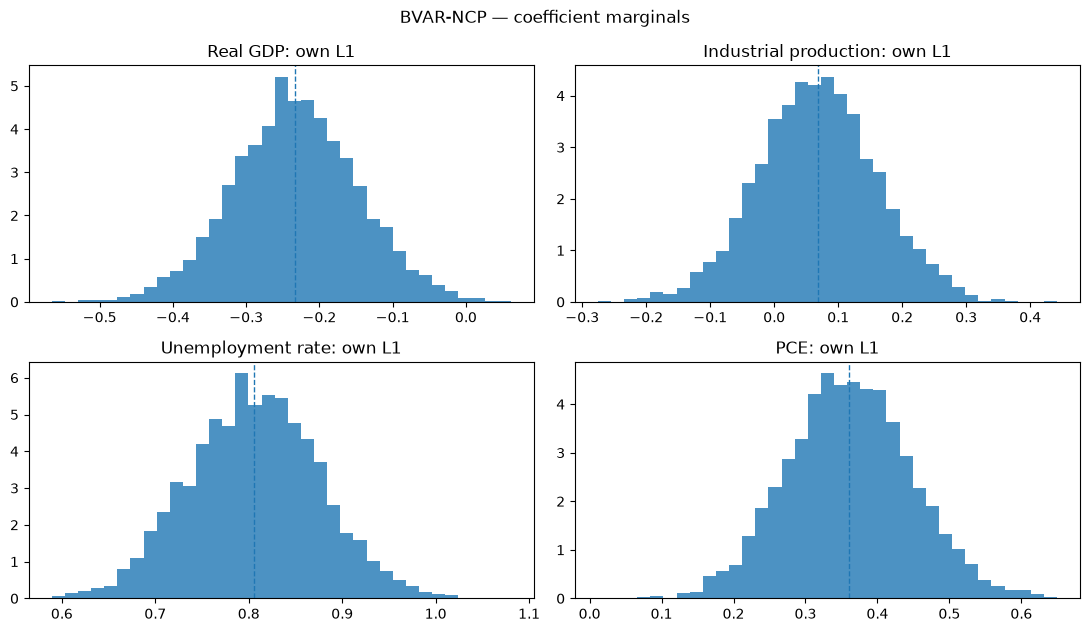

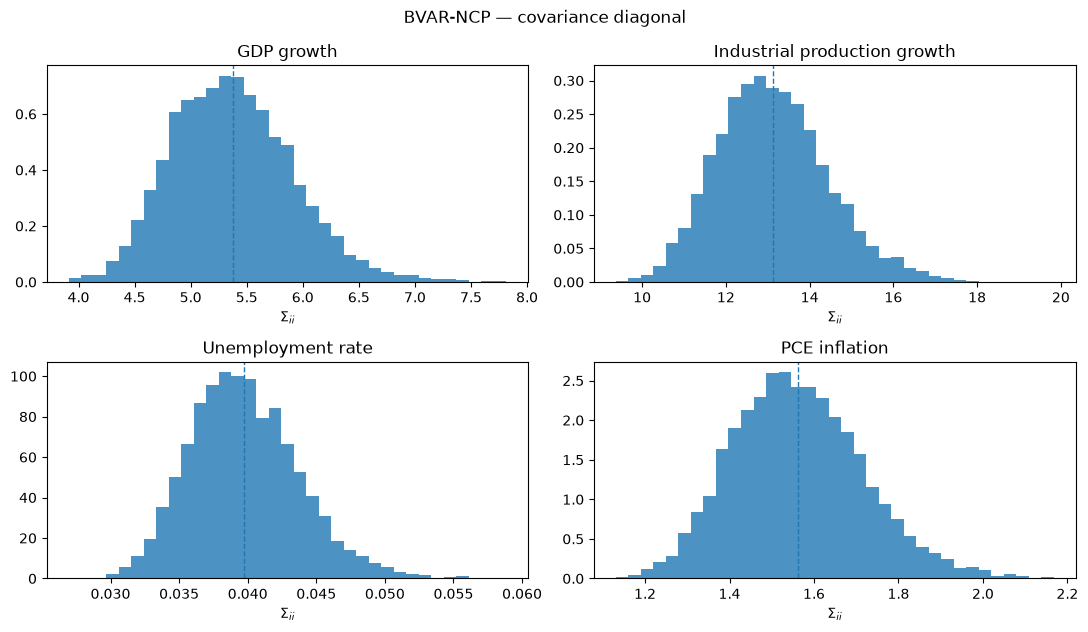

In [17]:
if active_mcmc_parameters(fit_ncp):
    plot_mcmc_traces(fit_ncp);
    plot_mcmc_marginals(fit_ncp);
else:
    plot_coefficient_traces(fit_ncp);
    plot_coefficient_marginals(fit_ncp);

plot_sigma_diagonal(fit_ncp);

### Results — one-origin predictive distribution and fan forecast

,actual,posterior mean forecast,log predictive likelihood
Real GDP,0.4837,2.5418,-2.1734
Real consumption,2.6345,2.6803,-1.6529
Business fixed investment,-5.1971,2.3721,-3.5242
Residential investment,7.0848,6.6139,-3.3399
Net exports,-571.5000,-545.4709,-4.7259
Nonfarm payrolls / income proxy,3.6618,2.7128,-2.0259
Industrial production,-3.7210,1.2686,-3.1053
Unemployment rate,5.0000,5.1331,0.4304
Employment,1.9679,1.5557,-0.9510
Hours,2.6316,1.1823,-1.8601


joint log predictive likelihood: -40.8749


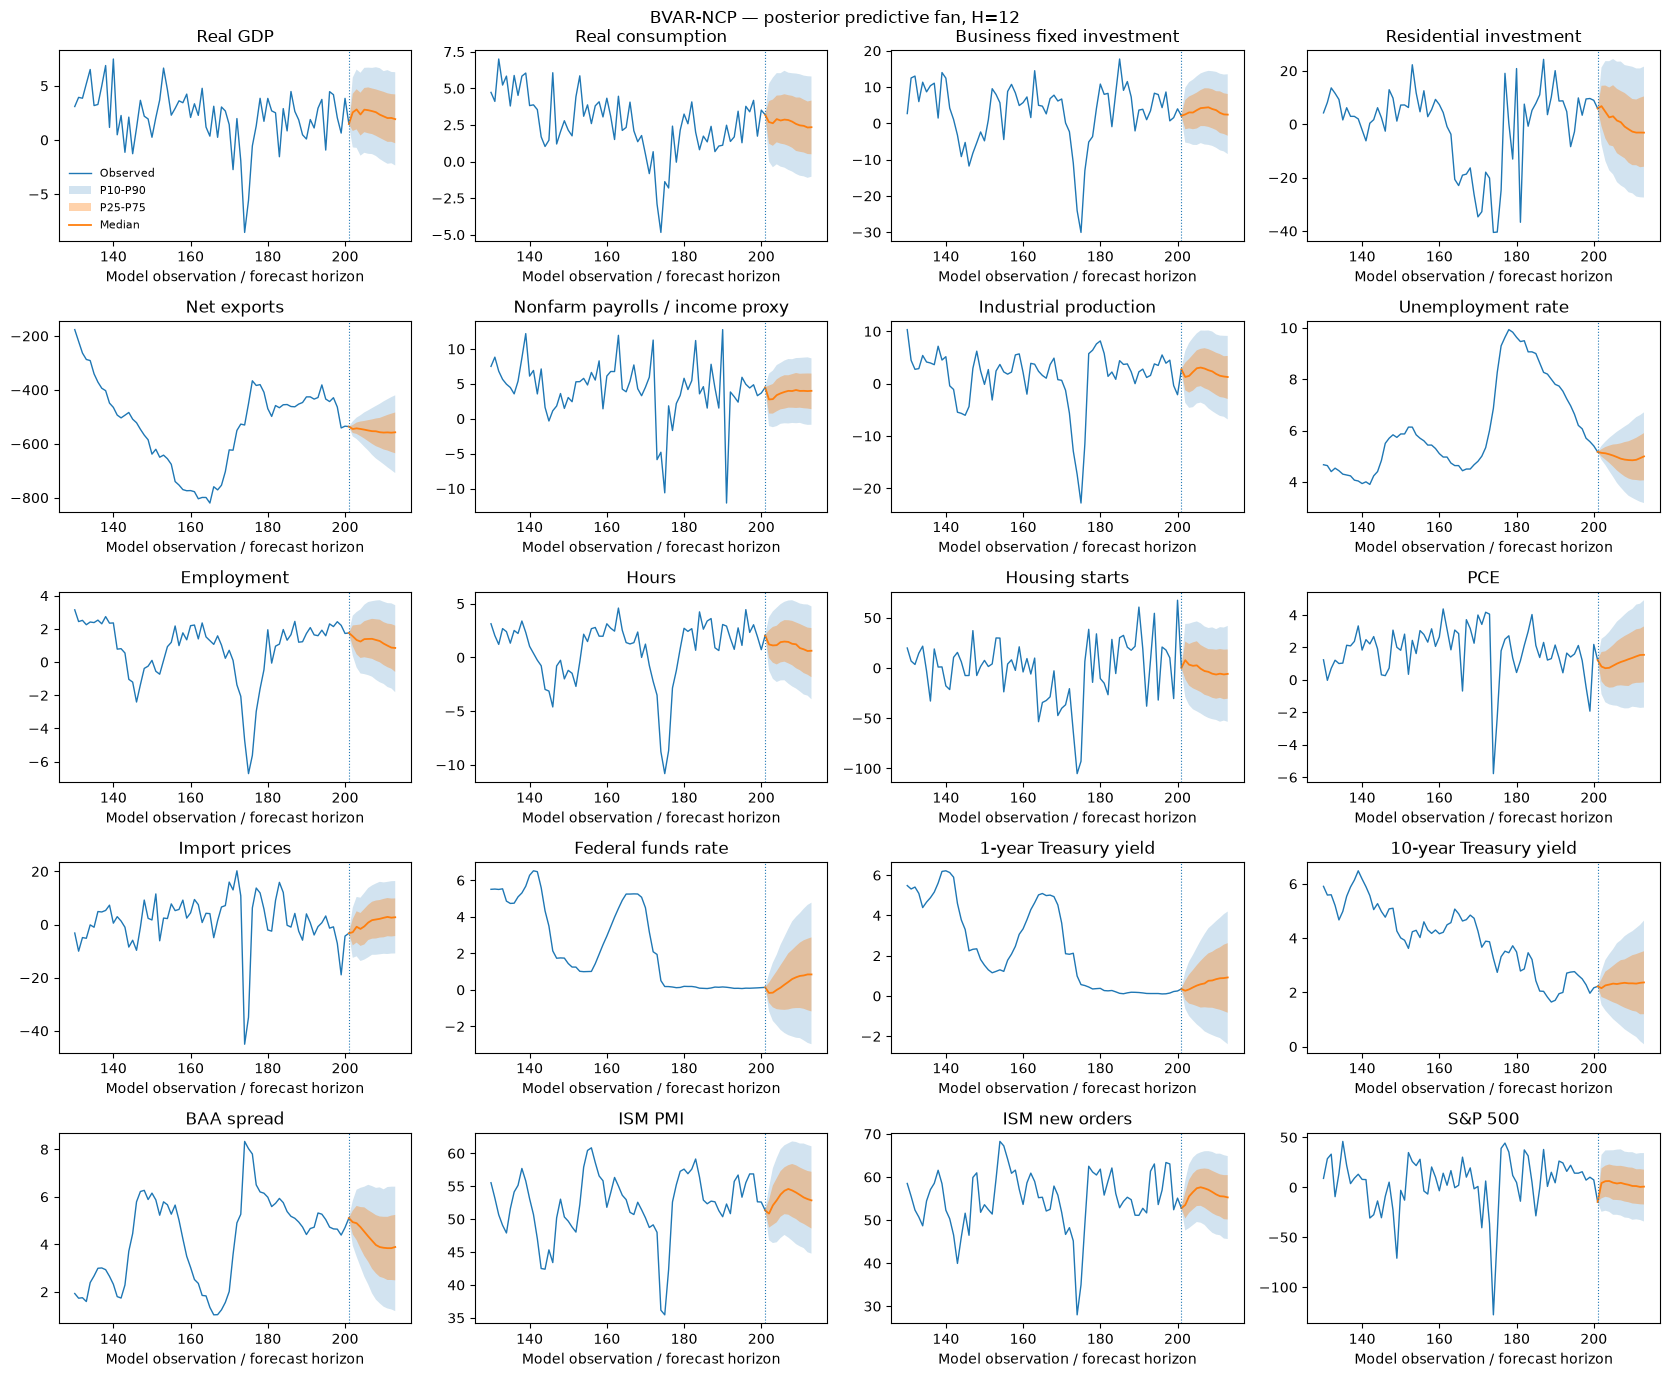

In [18]:
tmp0_ncp, tmp1_ncp = forecast_origin_from_fit(
    fit_ncp,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_ncp, lpl0_ncp = aggregate_forecast_draws(tmp0_ncp, n=len(FULL_VARIABLE_LABELS))

origin_table_ncp = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_ncp,
        "log predictive likelihood": lpl0_ncp[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_ncp.round(4))
print("joint log predictive likelihood:", round(float(lpl0_ncp[-1]), 4))

fan_ncp = forecast_paths_from_fit(
    fit_ncp,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_ncp);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

,median acceptance a_d,median A90 (deg),median R_d,median vMF kappa,draws measured
restriction set,,,,,
monetary policy,0.211,79.463,0.364,8.344,91


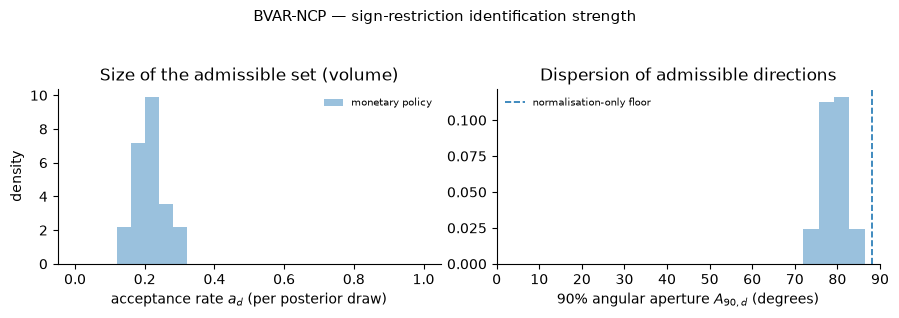

In [19]:
sign_strength_ncp = sign_identification_diagnostics(
    fit_ncp,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_ncp = plot_sign_identification(
    sign_strength_ncp,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_ncp)
plt.show()


searched posterior draws         250.000000
accepted draws                   190.000000
mean QR tries                      1.005263
median QR tries                    1.000000
flip share                         0.463158
unstable share among searched      0.240000
Name: sign restriction diagnostics, dtype: float64

FEVD normalization: base Sigma; common CSV/t scale excluded from horizon weighting
HD max reconstruction error: 2.069e-11


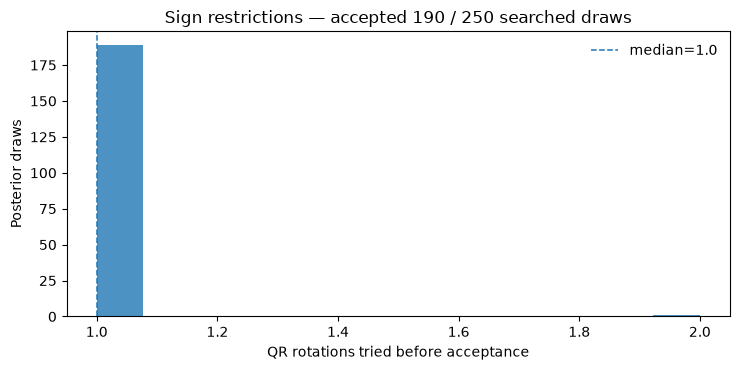

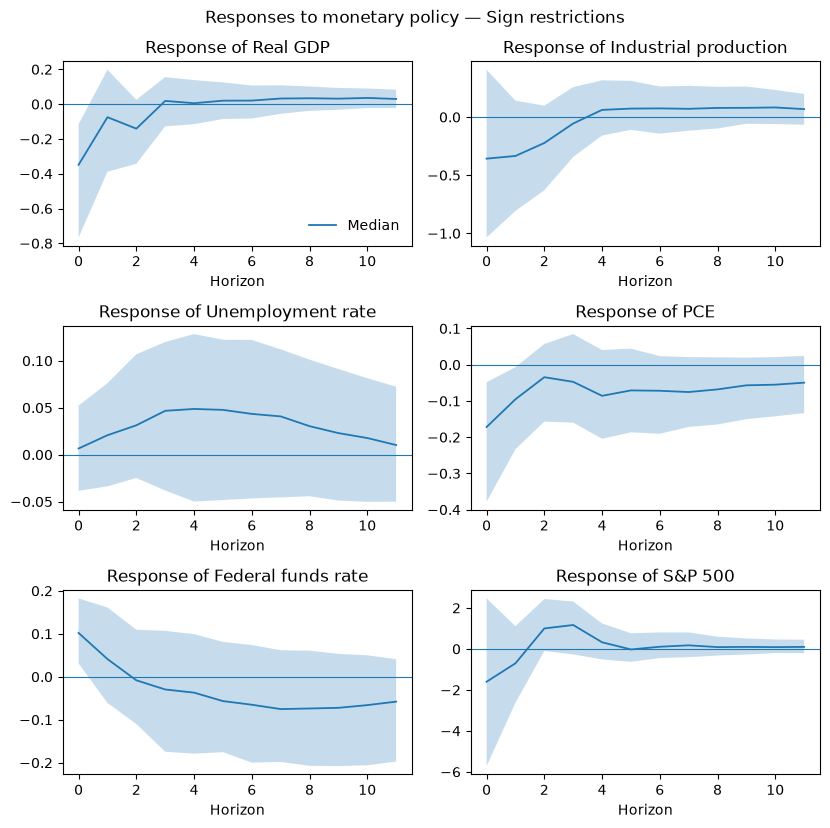

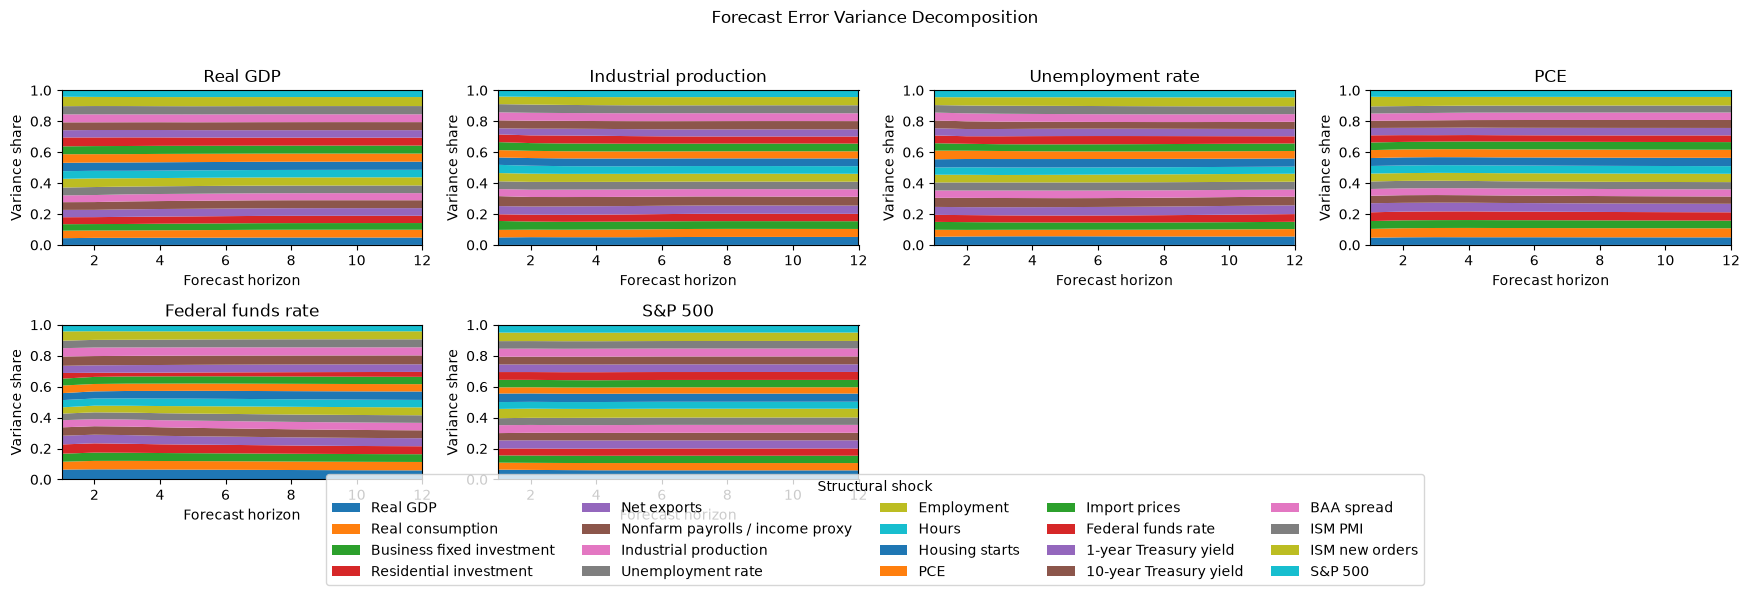

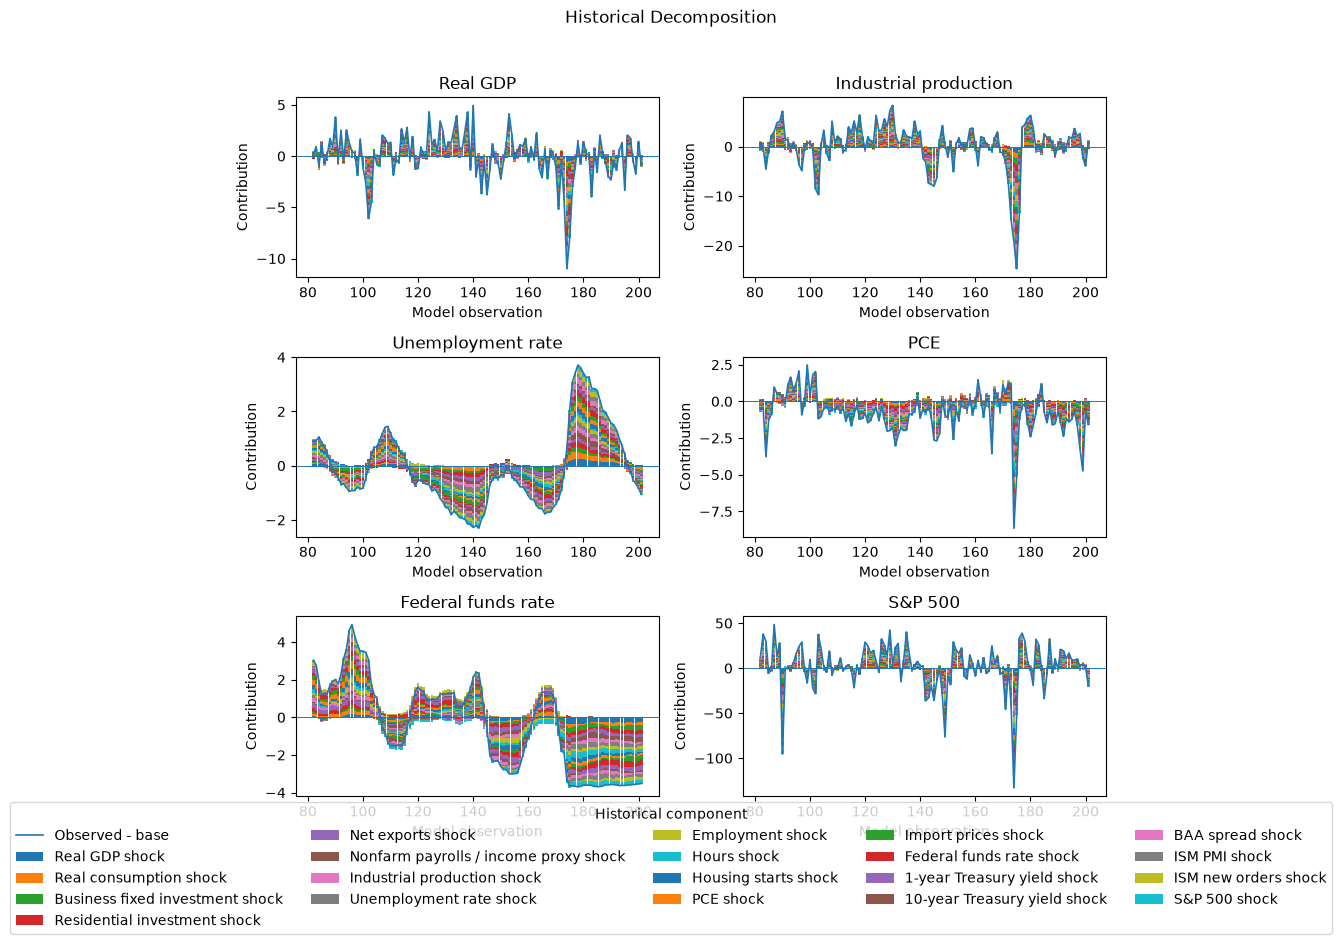

In [20]:
A0_ncp, sign_info_ncp = sign_restriction_draws(
    fit_ncp,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_ncp["n_candidates"],
    "accepted draws": sign_info_ncp["n_used"],
    "mean QR tries": sign_info_ncp["mean_tries"],
    "median QR tries": sign_info_ncp["median_tries"],
    "flip share": sign_info_ncp["flip_share"],
    "unstable share among searched": sign_info_ncp["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_ncp);

irf_ncp, irf_info_ncp = impulse_responses(
    fit_ncp,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_ncp,
    A0_draw_indices=sign_info_ncp["used_draw_indices"],
)
plot_irf_grid(
    irf_ncp,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_ncp, fevd_info_ncp = forecast_error_variance_decomposition(
    fit_ncp,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_ncp,
    A0_draw_indices=sign_info_ncp["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_ncp["normalization"])
plot_fevd(
    fevd_ncp,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_ncp, hd_info_ncp = historical_decomposition(
    fit_ncp,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_ncp,
    A0_draw_indices=sign_info_ncp["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_ncp['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_ncp,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_ncp

# Model 3 — BVAR-IP

## Specification, prior and algorithm

BVAR-IP uses the Minnesota coefficient prior as an **independent Normal prior** and places an inverse-Wishart prior on the unrestricted residual covariance matrix:

$$
\beta \sim N(\beta_0,V_\beta),
\qquad
\Sigma\sim IW(S_0,\nu_0),
$$

with the coefficient prior independent of $\Sigma$. This breaks the natural-conjugate Kronecker link and therefore requires Gibbs sampling.

For each iteration:

1. draw the complete stacked coefficient vector $\beta\mid\Sigma,y$ jointly;
2. reshape it into the 20-equation coefficient matrix $A$;
3. draw $\Sigma\mid A,y$ from the inverse-Wishart posterior;
4. use the paired $(A,\Sigma)$ draw for forecasting.

In [21]:
config_ip = get_model_config("BVAR-IP", p=p)

if config_ip.prior == "ncp":
    prior_ip = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_ip.c1, c2=config_ip.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_ip["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_ip["nu0"])
    print("VA0 shape =", prior_ip["VA0"].shape)
else:
    prior_ip = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_ip.c1, c2=config_ip.c2, c3=config_ip.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_ip["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_ip["variance"].shape)

config_ip

,AR residual variance
Real GDP,9.253407
Real consumption,5.730322
Business fixed investment,44.098745
Residential investment,248.621489
Net exports,437.428110
Nonfarm payrolls / income proxy,10.471118
Industrial production,22.430850
Unemployment rate,0.058817
Employment,1.332456
Hours,6.302005


Minnesota coefficient variances: (1620,)


BVARConfig(name='BVAR-IP', prior='ip', stochastic_volatility=False, student_t=False, ma1=False, p=4, c1=0.04000000000000001, c2=0.010000000000000002, c3=100.0, q=0.5, kappa1=10.0, rho0=0.9, Vrho=0.04000000000000001, nuh0=5.0, Sh0=0.04, rho_init=0.8, sigh2_init=0.1, nu_init=5.0, nu_upper=50.0, psi0=0.0, Vpsi=1.0, psi_init=0.1, psi_bound=0.99, psi_hessian_every=100)

### Estimation and posterior diagnostics

In [22]:
fit_ip = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_ip,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-IP"] = fit_ip

print(fit_ip["model_name"])
print(f"fitted equations        : {fit_ip['n']}")
print(f"coefficients / equation : {fit_ip['k']}")
print(f"total VAR coefficients  : {fit_ip['n'] * fit_ip['k']}")

if not fit_ip["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_ip["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_ip = fit_ip["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_ip.round(4))

print("MH / accept-reject acceptance shares:")
if fit_ip["acceptance"]:
    display(pd.Series(fit_ip["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

BVAR-IP
fitted equations        : 20
coefficients / equation : 81
total VAR coefficients  : 1620
No additional scalar latent state is sampled in this specification.
Posterior mean of every coefficient — 81 regressors x 20 equations


equation,1-year Treasury yield,10-year Treasury yield,BAA spread,Business fixed investment,Employment,Federal funds rate,Hours,Housing starts,ISM PMI,ISM new orders,Import prices,Industrial production,Net exports,Nonfarm payrolls / income proxy,PCE,Real GDP,Real consumption,Residential investment,S&P 500,Unemployment rate
coefficient,,,,,,,,,,,,,,,,,,,,
1-year Treasury yield L1,0.7874,-0.0229,-0.0889,-0.0331,0.1477,0.2039,-0.0599,-2.6291,-0.2788,-0.6403,-0.2328,0.3901,2.2552,0.0774,0.0657,-0.2724,0.1447,-1.4212,1.6437,0.0179
1-year Treasury yield L2,0.0234,-0.0048,-0.0061,-0.1786,0.0148,-0.0485,-0.1374,3.2555,0.0653,-0.0795,0.0405,0.2341,0.6237,-0.0162,0.0284,-0.0630,0.1110,0.5466,1.0462,-0.0006
1-year Treasury yield L3,0.0358,0.0071,-0.0267,-0.1693,-0.0128,0.0175,0.0348,0.7800,0.0123,-0.0916,0.1276,0.1048,0.1373,0.0235,-0.0146,0.1436,0.0369,0.2082,0.3393,0.0047
1-year Treasury yield L4,-0.0335,0.0067,-0.0113,-0.1078,-0.0038,0.0004,-0.0063,0.0947,0.0392,-0.0540,0.0098,0.0585,0.1626,-0.0110,0.0021,0.0134,0.0606,0.3617,-0.3304,0.0022
10-year Treasury yield L1,0.0664,0.9500,0.0554,1.2051,-0.1013,0.0027,0.2847,-4.0244,-0.2500,0.4628,-1.1493,-0.1737,-2.1449,0.0152,-0.0239,0.3656,-0.3386,-3.1363,-3.6946,0.0006
10-year Treasury yield L2,0.0181,-0.0496,0.0252,-0.1995,0.0136,-0.0674,-0.1514,4.3134,0.0688,-0.0174,-0.1353,0.0696,-0.1586,0.0600,-0.0052,-0.1410,0.1439,0.8670,0.7064,-0.0118
10-year Treasury yield L3,-0.0012,-0.0127,-0.0154,-0.2140,-0.0010,0.0411,0.1698,-0.0886,-0.0856,0.0606,0.2169,-0.1335,-0.3279,0.0167,-0.0282,0.0607,0.0420,1.2100,0.9702,-0.0065
10-year Treasury yield L4,-0.0079,-0.0187,-0.0283,-0.1756,0.0110,-0.0080,0.0449,-0.8337,-0.0593,0.0849,0.1822,-0.1635,0.0702,-0.0527,-0.0071,0.0547,0.0516,1.1948,-0.1438,-0.0013
BAA spread L1,0.0156,0.0043,0.7880,-0.4695,0.0087,0.0392,-0.1748,1.7658,0.3942,0.2645,-0.4002,-0.2244,0.7354,-0.2035,-0.1440,0.0469,0.2719,1.6114,0.5913,0.0188


MH / accept-reject acceptance shares:
No MH / acceptance-rejection block in this specification.


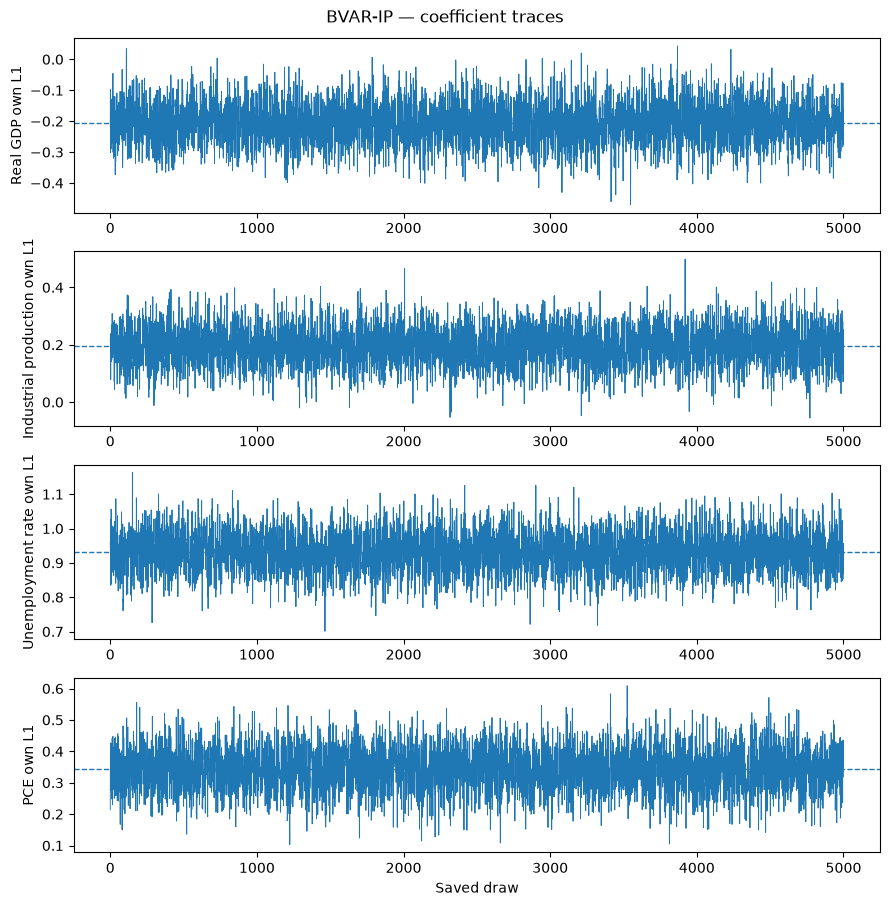

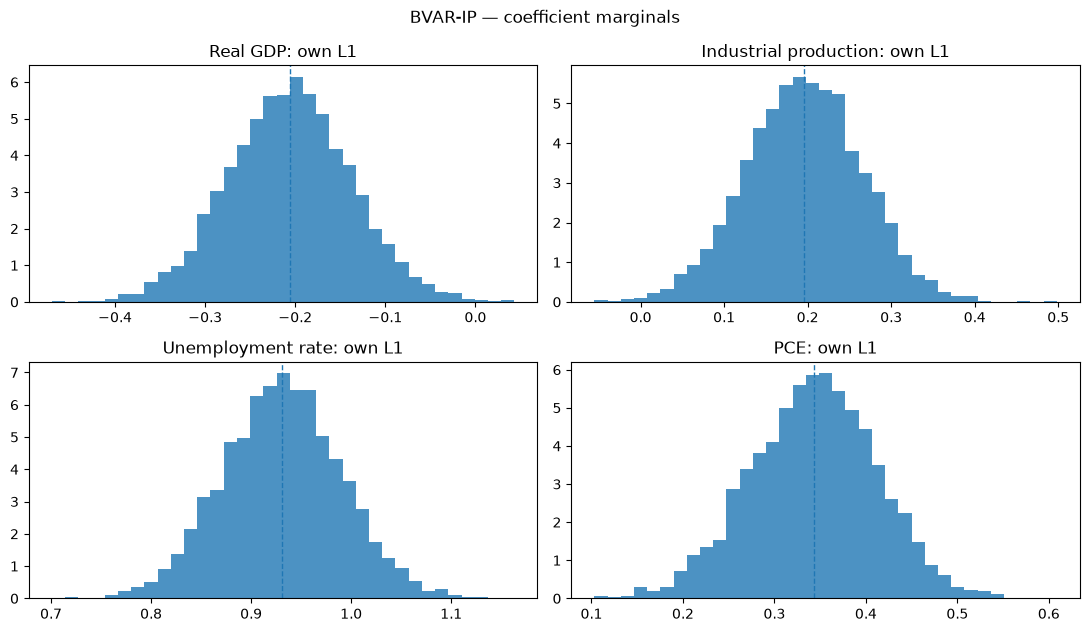

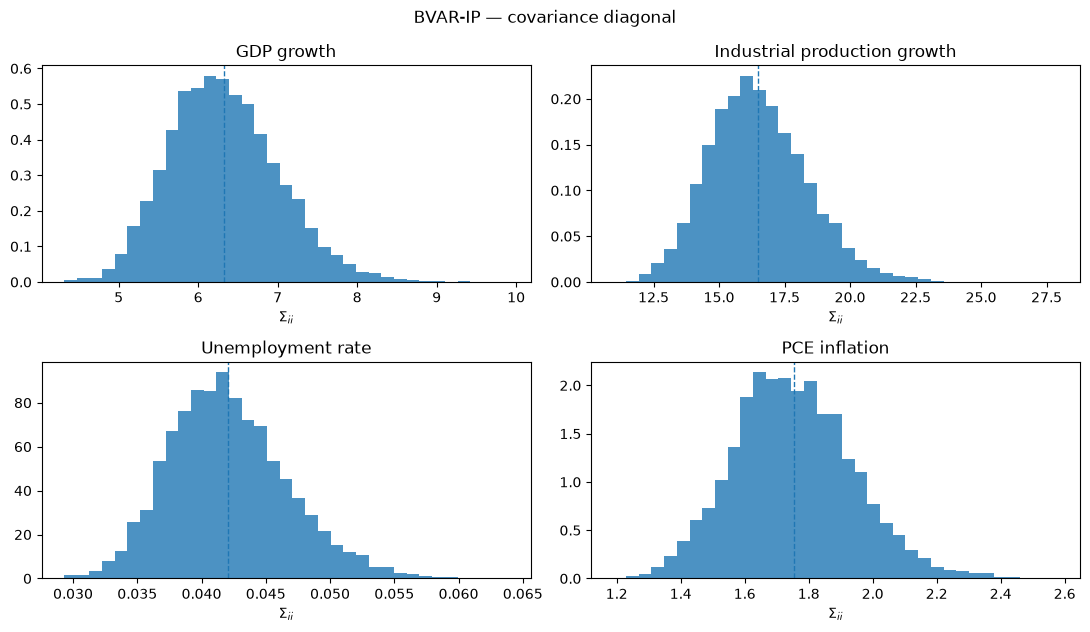

In [23]:
if active_mcmc_parameters(fit_ip):
    plot_mcmc_traces(fit_ip);
    plot_mcmc_marginals(fit_ip);
else:
    plot_coefficient_traces(fit_ip);
    plot_coefficient_marginals(fit_ip);

plot_sigma_diagonal(fit_ip);

### Diagnosis — MCMC mixing and Monte Carlo precision



,post. mean,post. sd,ESS,ESS/share,MCSE,MCSE/sd,ACF(1)
A[Real GDP <- L1 Real GDP],-0.2062,0.0680,4990.1719,0.9980,0.0010,0.0142,0.0010
A[Industrial production <- L1 Industrial production],0.1955,0.0694,4493.2888,0.8987,0.0010,0.0149,0.0269
A[Unemployment rate <- L1 Unemployment rate],0.9308,0.0589,4397.3466,0.8795,0.0009,0.0151,0.0418
A[PCE <- L1 PCE],0.3429,0.0690,4244.9447,0.8490,0.0011,0.0153,0.0269
"Sigma[Real GDP,Real GDP]",6.3300,0.6907,3394.1544,0.6788,0.0119,0.0172,0.1981
"Sigma[Industrial production,Industrial production]",16.4987,1.8655,2810.3884,0.5621,0.0352,0.0189,0.2372
"Sigma[Unemployment rate,Unemployment rate]",0.0421,0.0046,3039.2667,0.6079,0.0001,0.0181,0.2115
"Sigma[PCE,PCE]",1.7539,0.1881,3562.3199,0.7125,0.0032,0.0168,0.1499
log det(Sigma),21.0605,0.4673,3305.5747,0.6611,0.0081,0.0174,0.1709


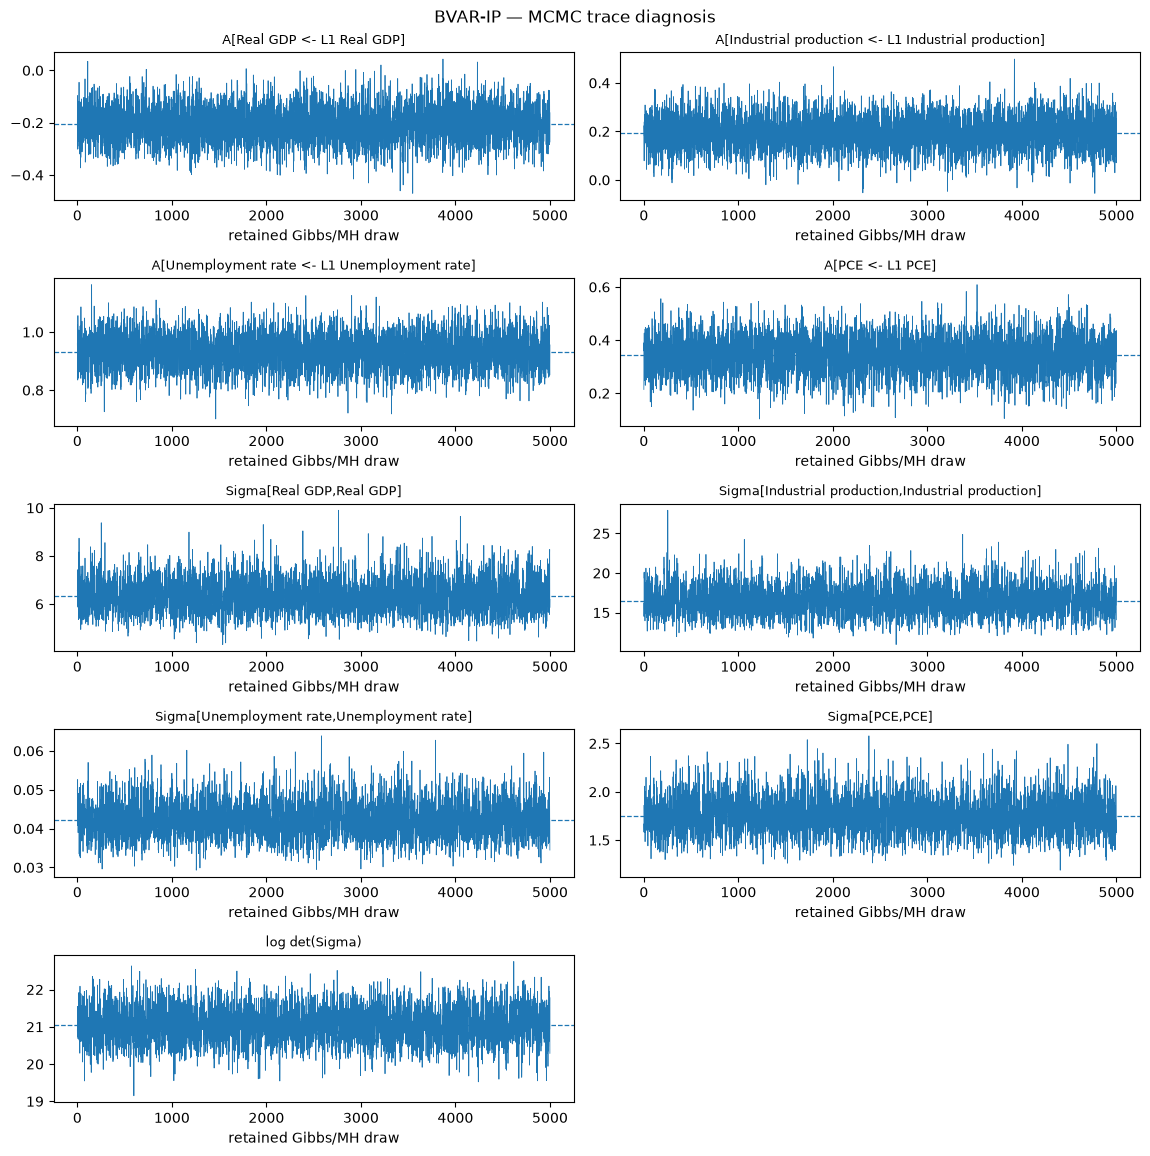

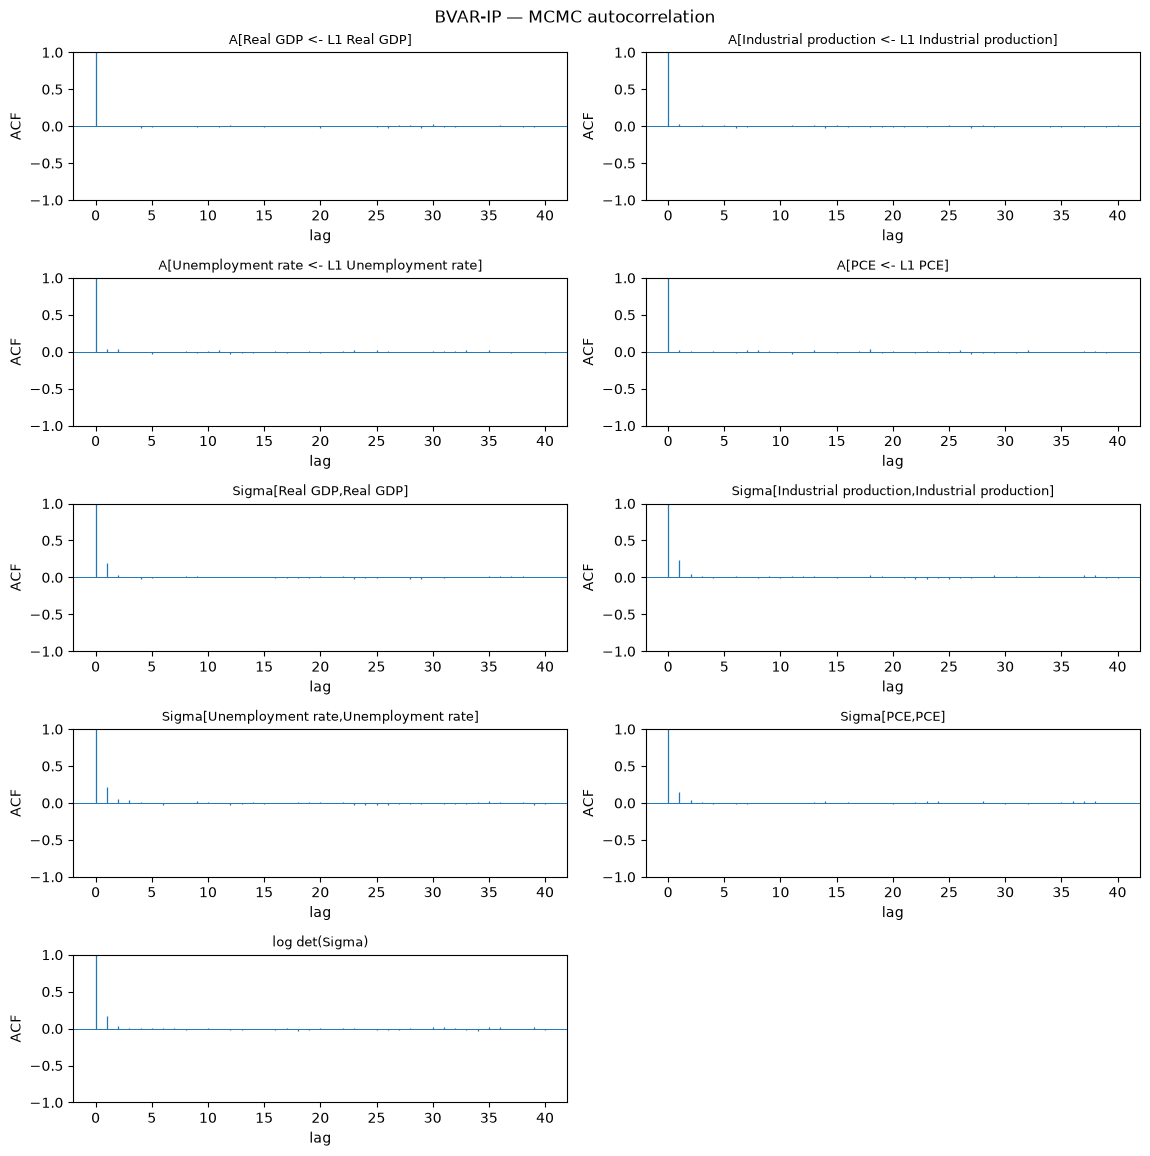

In [24]:
mcmc_diag_ip = bvar_mcmc_diagnostics(
    fit_ip,
    acf_lags=MCMC_DIAG_MAX_LAG,
)

display(mcmc_diag_ip["table"].round(4))
if not mcmc_diag_ip["acceptance"].empty:
    print("Sampler acceptance shares")
    display(mcmc_diag_ip["acceptance"].round(4))

plot_mcmc_diagnostic_traces(mcmc_diag_ip);
plot_mcmc_diagnostic_acf(
    mcmc_diag_ip,
    max_lag=MCMC_DIAG_MAX_LAG,
);


### Results — one-origin predictive distribution and fan forecast

,actual,posterior mean forecast,log predictive likelihood
Real GDP,0.4837,2.8231,-2.2797
Real consumption,2.6345,2.7883,-1.7024
Business fixed investment,-5.1971,2.9699,-3.6111
Residential investment,7.0848,6.8405,-3.3503
Net exports,-571.5000,-542.5200,-4.9470
Nonfarm payrolls / income proxy,3.6618,2.9668,-2.0504
Industrial production,-3.7210,2.1773,-3.3485
Unemployment rate,5.0000,5.0957,0.5314
Employment,1.9679,1.7064,-0.9450
Hours,2.6316,1.4110,-1.8156


joint log predictive likelihood: -39.9537


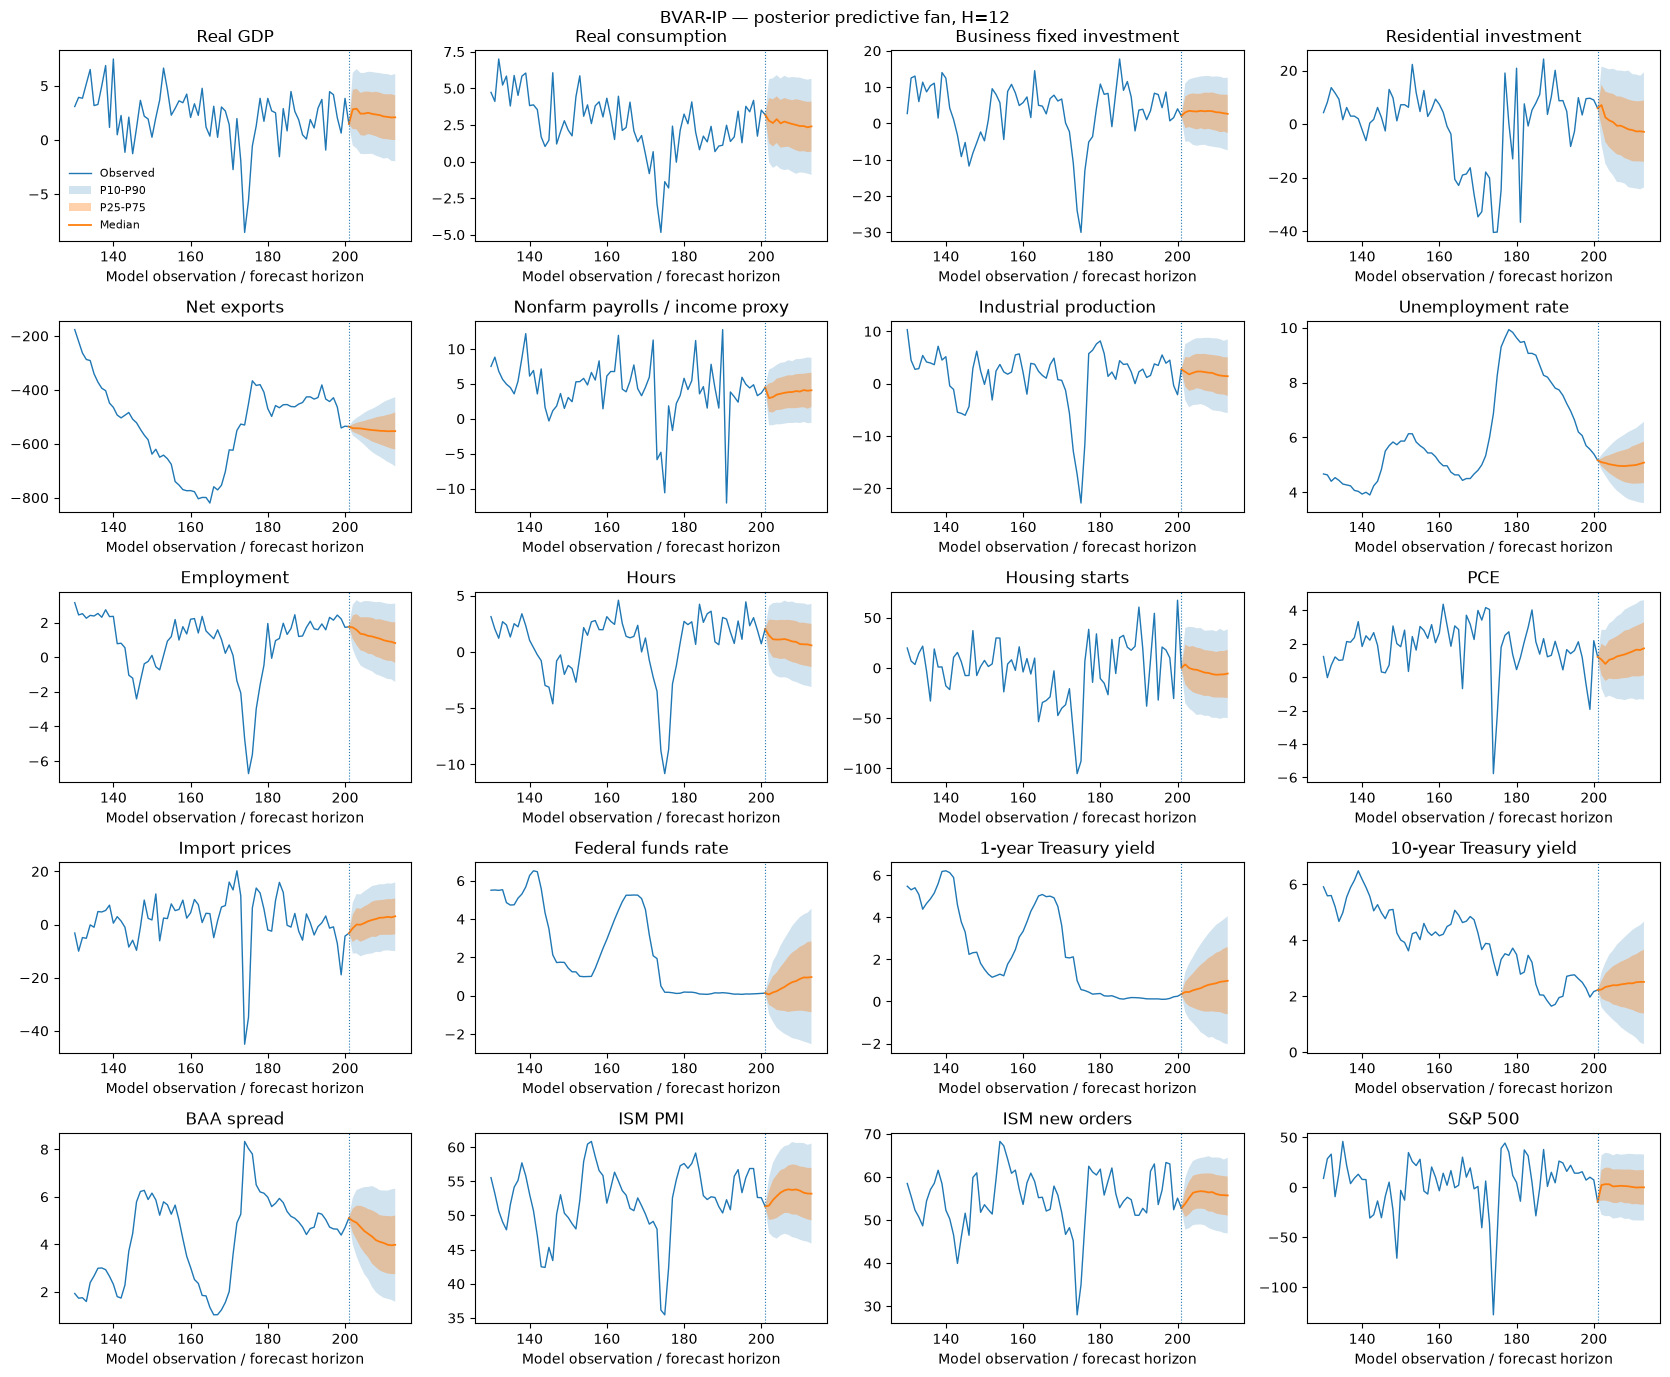

In [25]:
tmp0_ip, tmp1_ip = forecast_origin_from_fit(
    fit_ip,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_ip, lpl0_ip = aggregate_forecast_draws(tmp0_ip, n=len(FULL_VARIABLE_LABELS))

origin_table_ip = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_ip,
        "log predictive likelihood": lpl0_ip[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_ip.round(4))
print("joint log predictive likelihood:", round(float(lpl0_ip[-1]), 4))

fan_ip = forecast_paths_from_fit(
    fit_ip,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_ip);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

,median acceptance a_d,median A90 (deg),median R_d,median vMF kappa,draws measured
restriction set,,,,,
monetary policy,0.195,79.98,0.364,8.324,95


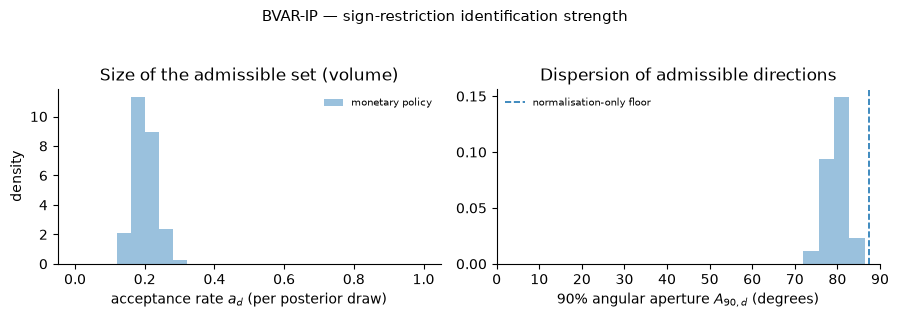

In [26]:
sign_strength_ip = sign_identification_diagnostics(
    fit_ip,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_ip = plot_sign_identification(
    sign_strength_ip,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_ip)
plt.show()


searched posterior draws         250.000000
accepted draws                   211.000000
mean QR tries                      1.004739
median QR tries                    1.000000
flip share                         0.488152
unstable share among searched      0.156000
Name: sign restriction diagnostics, dtype: float64

FEVD normalization: base Sigma; common CSV/t scale excluded from horizon weighting
HD max reconstruction error: 1.546e-11


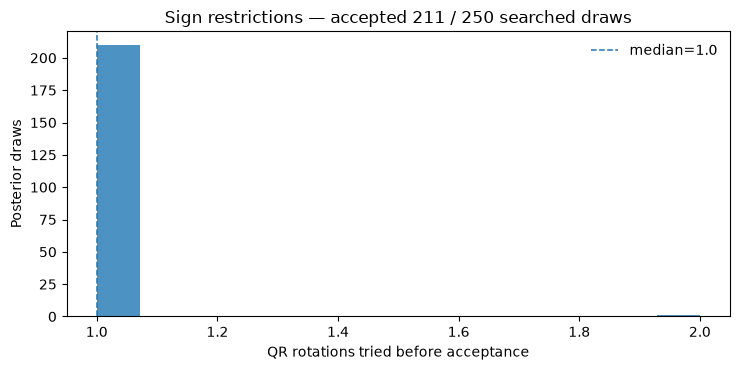

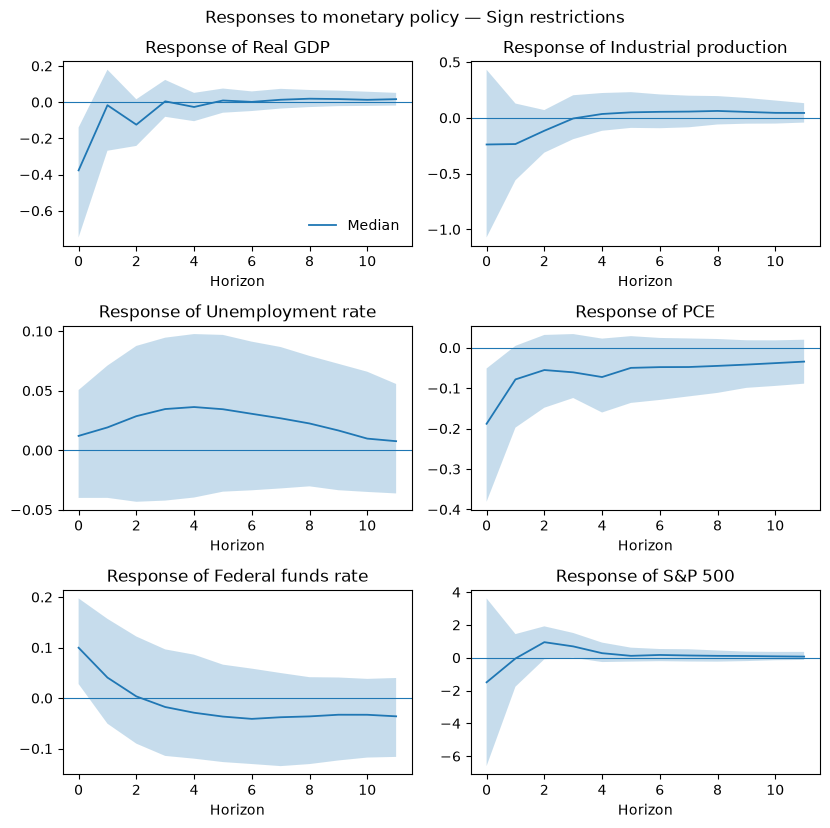

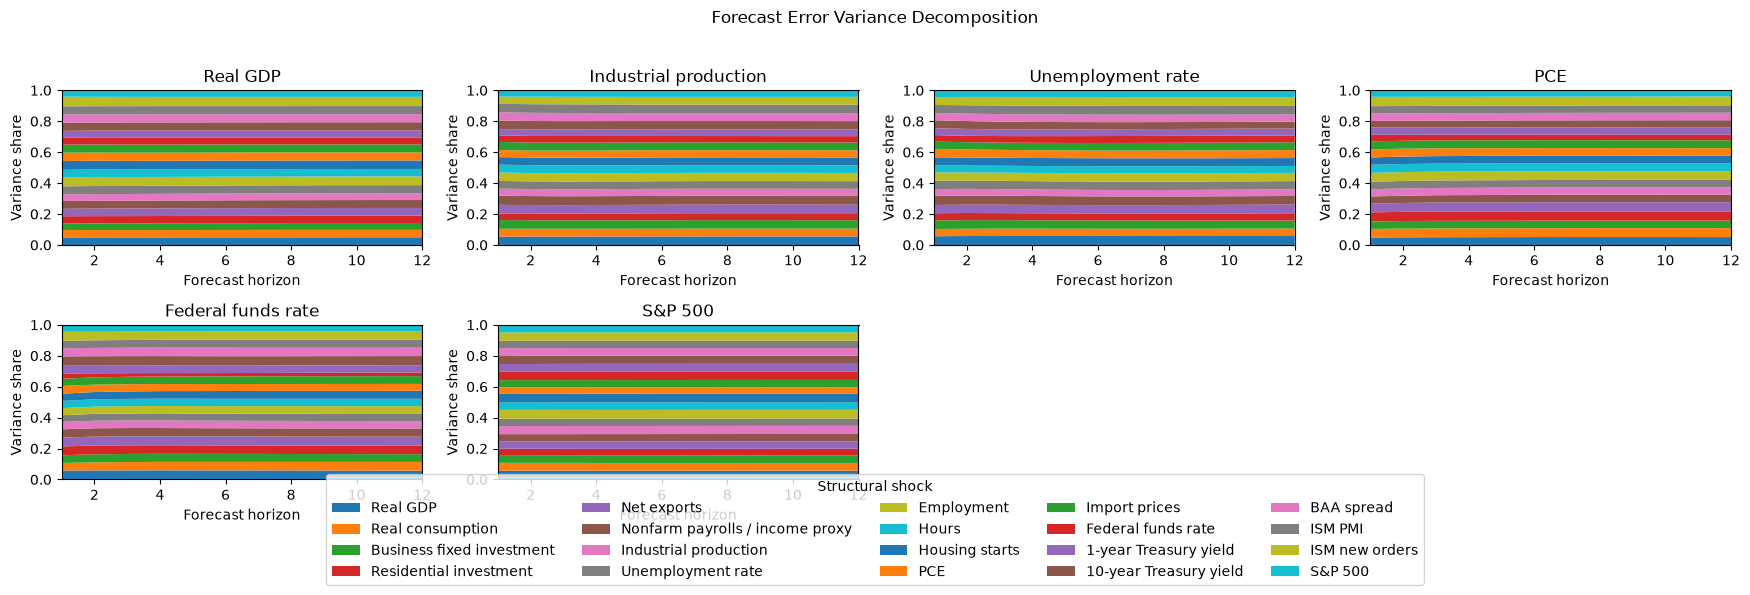

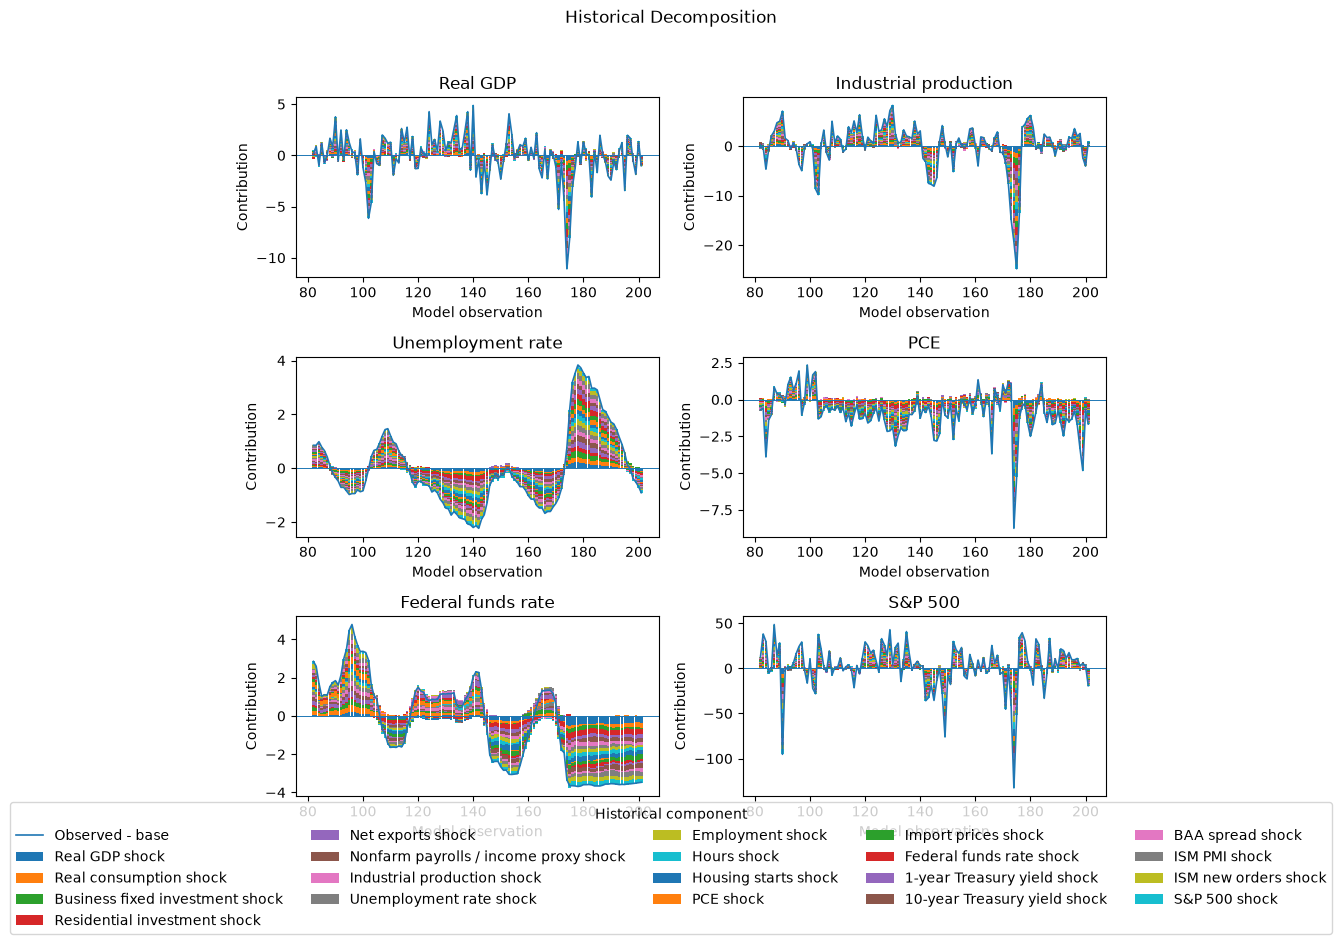

In [27]:
A0_ip, sign_info_ip = sign_restriction_draws(
    fit_ip,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_ip["n_candidates"],
    "accepted draws": sign_info_ip["n_used"],
    "mean QR tries": sign_info_ip["mean_tries"],
    "median QR tries": sign_info_ip["median_tries"],
    "flip share": sign_info_ip["flip_share"],
    "unstable share among searched": sign_info_ip["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_ip);

irf_ip, irf_info_ip = impulse_responses(
    fit_ip,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_ip,
    A0_draw_indices=sign_info_ip["used_draw_indices"],
)
plot_irf_grid(
    irf_ip,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_ip, fevd_info_ip = forecast_error_variance_decomposition(
    fit_ip,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_ip,
    A0_draw_indices=sign_info_ip["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_ip["normalization"])
plot_fevd(
    fevd_ip,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_ip, hd_info_ip = historical_decomposition(
    fit_ip,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_ip,
    A0_draw_indices=sign_info_ip["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_ip['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_ip,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_ip

# Model 4 — BVAR-SSVS

## Specification, prior and algorithm

BVAR-SSVS starts from the independent-prior BVAR and adds a stochastic-search variable-selection indicator for every VAR coefficient. Conditional on indicator $\gamma_j$, the prior variance switches between a tightly shrunk Minnesota variance and the slab variance $\kappa_1$.

With Chan's settings,

$$
P(\gamma_j=1)=q=0.5,
\qquad
\kappa_1=10.
$$

Each Gibbs iteration performs:

1. draw all VAR coefficients jointly conditional on $(\Sigma,\gamma)$;
2. draw $\Sigma$ from its inverse-Wishart conditional posterior;
3. draw every inclusion indicator $\gamma_j$ from its Bernoulli conditional posterior;
4. retain `gamma_share`, the fraction of coefficients currently in the slab state.

There is no CSV, Student-t or MA component.

In [28]:
config_ssvs = get_model_config("BVAR-SSVS", p=p)

if config_ssvs.prior == "ncp":
    prior_ssvs = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_ssvs.c1, c2=config_ssvs.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_ssvs["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_ssvs["nu0"])
    print("VA0 shape =", prior_ssvs["VA0"].shape)
else:
    prior_ssvs = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_ssvs.c1, c2=config_ssvs.c2, c3=config_ssvs.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_ssvs["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_ssvs["variance"].shape)

config_ssvs

,AR residual variance
Real GDP,9.253407
Real consumption,5.730322
Business fixed investment,44.098745
Residential investment,248.621489
Net exports,437.428110
Nonfarm payrolls / income proxy,10.471118
Industrial production,22.430850
Unemployment rate,0.058817
Employment,1.332456
Hours,6.302005


Minnesota coefficient variances: (1620,)


BVARConfig(name='BVAR-SSVS', prior='ssvs', stochastic_volatility=False, student_t=False, ma1=False, p=4, c1=0.04000000000000001, c2=0.010000000000000002, c3=100.0, q=0.5, kappa1=10.0, rho0=0.9, Vrho=0.04000000000000001, nuh0=5.0, Sh0=0.04, rho_init=0.8, sigh2_init=0.1, nu_init=5.0, nu_upper=50.0, psi0=0.0, Vpsi=1.0, psi_init=0.1, psi_bound=0.99, psi_hessian_every=100)

### Estimation and posterior diagnostics

In [29]:
fit_ssvs = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_ssvs,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-SSVS"] = fit_ssvs

print(fit_ssvs["model_name"])
print(f"fitted equations        : {fit_ssvs['n']}")
print(f"coefficients / equation : {fit_ssvs['k']}")
print(f"total VAR coefficients  : {fit_ssvs['n'] * fit_ssvs['k']}")

if not fit_ssvs["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_ssvs["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_ssvs = fit_ssvs["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_ssvs.round(4))

print("MH / accept-reject acceptance shares:")
if fit_ssvs["acceptance"]:
    display(pd.Series(fit_ssvs["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

RuntimeError: Joint coefficient CG solve did not converge (info=5000).

In [ ]:
if active_mcmc_parameters(fit_ssvs):
    plot_mcmc_traces(fit_ssvs);
    plot_mcmc_marginals(fit_ssvs);
else:
    plot_coefficient_traces(fit_ssvs);
    plot_coefficient_marginals(fit_ssvs);

plot_sigma_diagonal(fit_ssvs);

### Diagnosis — MCMC mixing and Monte Carlo precision



In [ ]:
mcmc_diag_ssvs = bvar_mcmc_diagnostics(
    fit_ssvs,
    acf_lags=MCMC_DIAG_MAX_LAG,
)

display(mcmc_diag_ssvs["table"].round(4))
if not mcmc_diag_ssvs["acceptance"].empty:
    print("Sampler acceptance shares")
    display(mcmc_diag_ssvs["acceptance"].round(4))

plot_mcmc_diagnostic_traces(mcmc_diag_ssvs);
plot_mcmc_diagnostic_acf(
    mcmc_diag_ssvs,
    max_lag=MCMC_DIAG_MAX_LAG,
);


### Results — one-origin predictive distribution and fan forecast

In [ ]:
tmp0_ssvs, tmp1_ssvs = forecast_origin_from_fit(
    fit_ssvs,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_ssvs, lpl0_ssvs = aggregate_forecast_draws(tmp0_ssvs, n=len(FULL_VARIABLE_LABELS))

origin_table_ssvs = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_ssvs,
        "log predictive likelihood": lpl0_ssvs[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_ssvs.round(4))
print("joint log predictive likelihood:", round(float(lpl0_ssvs[-1]), 4))

fan_ssvs = forecast_paths_from_fit(
    fit_ssvs,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_ssvs);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

In [ ]:
sign_strength_ssvs = sign_identification_diagnostics(
    fit_ssvs,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_ssvs = plot_sign_identification(
    sign_strength_ssvs,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_ssvs)
plt.show()


In [ ]:
A0_ssvs, sign_info_ssvs = sign_restriction_draws(
    fit_ssvs,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_ssvs["n_candidates"],
    "accepted draws": sign_info_ssvs["n_used"],
    "mean QR tries": sign_info_ssvs["mean_tries"],
    "median QR tries": sign_info_ssvs["median_tries"],
    "flip share": sign_info_ssvs["flip_share"],
    "unstable share among searched": sign_info_ssvs["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_ssvs);

irf_ssvs, irf_info_ssvs = impulse_responses(
    fit_ssvs,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_ssvs,
    A0_draw_indices=sign_info_ssvs["used_draw_indices"],
)
plot_irf_grid(
    irf_ssvs,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_ssvs, fevd_info_ssvs = forecast_error_variance_decomposition(
    fit_ssvs,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_ssvs,
    A0_draw_indices=sign_info_ssvs["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_ssvs["normalization"])
plot_fevd(
    fevd_ssvs,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_ssvs, hd_info_ssvs = historical_decomposition(
    fit_ssvs,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_ssvs,
    A0_draw_indices=sign_info_ssvs["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_ssvs['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_ssvs,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_ssvs

# Model 5 — BVAR-CSV

## Specification, prior and algorithm

BVAR-CSV extends the natural-conjugate BVAR with a **common stochastic volatility** factor:

$$
u_t\mid h_t,\Sigma \sim N(0,e^{h_t}\Sigma),
$$

$$
h_t=\rho h_{t-1}+\eta_t,
\qquad
\eta_t\sim N(0,\sigma_h^2).
$$

The common scalar $e^{h_t}$ changes the overall innovation scale through time while $\Sigma$ controls the cross-sectional covariance pattern.

Each iteration performs:

1. draw $\Sigma$ and $A$ conditional on the current volatility path $h$;
2. draw the complete path $h_{1:T}$ using Chan's acceptance-rejection / MH volatility sampler;
3. draw $\sigma_h^2$;
4. MH-update the persistence parameter $\rho$.

Student-t scales and MA errors are switched off.

In [30]:
config_csv = get_model_config("BVAR-CSV", p=p)

if config_csv.prior == "ncp":
    prior_csv = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_csv.c1, c2=config_csv.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_csv["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_csv["nu0"])
    print("VA0 shape =", prior_csv["VA0"].shape)
else:
    prior_csv = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_csv.c1, c2=config_csv.c2, c3=config_csv.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_csv["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_csv["variance"].shape)

config_csv

,AR residual variance
Real GDP,9.253407
Real consumption,5.730322
Business fixed investment,44.098745
Residential investment,248.621489
Net exports,437.428110
Nonfarm payrolls / income proxy,10.471118
Industrial production,22.430850
Unemployment rate,0.058817
Employment,1.332456
Hours,6.302005


nu0 = 23
VA0 shape = (81,)


BVARConfig(name='BVAR-CSV', prior='ncp', stochastic_volatility=True, student_t=False, ma1=False, p=4, c1=0.04000000000000001, c2=100.0, c3=100.0, q=0.5, kappa1=10.0, rho0=0.9, Vrho=0.04000000000000001, nuh0=5.0, Sh0=0.04, rho_init=0.8, sigh2_init=0.1, nu_init=5.0, nu_upper=50.0, psi0=0.0, Vpsi=1.0, psi_init=0.1, psi_bound=0.99, psi_hessian_every=100)

### Estimation and posterior diagnostics

In [31]:
fit_csv = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_csv,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-CSV"] = fit_csv

print(fit_csv["model_name"])
print(f"fitted equations        : {fit_csv['n']}")
print(f"coefficients / equation : {fit_csv['k']}")
print(f"total VAR coefficients  : {fit_csv['n'] * fit_csv['k']}")

if not fit_csv["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_csv["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_csv = fit_csv["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_csv.round(4))

print("MH / accept-reject acceptance shares:")
if fit_csv["acceptance"]:
    display(pd.Series(fit_csv["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

KeyboardInterrupt: 

In [ ]:
if active_mcmc_parameters(fit_csv):
    plot_mcmc_traces(fit_csv);
    plot_mcmc_marginals(fit_csv);
else:
    plot_coefficient_traces(fit_csv);
    plot_coefficient_marginals(fit_csv);

plot_sigma_diagonal(fit_csv);

### Diagnosis — MCMC mixing and Monte Carlo precision



In [ ]:
mcmc_diag_csv = bvar_mcmc_diagnostics(
    fit_csv,
    acf_lags=MCMC_DIAG_MAX_LAG,
)

display(mcmc_diag_csv["table"].round(4))
if not mcmc_diag_csv["acceptance"].empty:
    print("Sampler acceptance shares")
    display(mcmc_diag_csv["acceptance"].round(4))

plot_mcmc_diagnostic_traces(mcmc_diag_csv);
plot_mcmc_diagnostic_acf(
    mcmc_diag_csv,
    max_lag=MCMC_DIAG_MAX_LAG,
);


### Results — one-origin predictive distribution and fan forecast

In [ ]:
tmp0_csv, tmp1_csv = forecast_origin_from_fit(
    fit_csv,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_csv, lpl0_csv = aggregate_forecast_draws(tmp0_csv, n=len(FULL_VARIABLE_LABELS))

origin_table_csv = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_csv,
        "log predictive likelihood": lpl0_csv[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_csv.round(4))
print("joint log predictive likelihood:", round(float(lpl0_csv[-1]), 4))

fan_csv = forecast_paths_from_fit(
    fit_csv,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_csv);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

In [ ]:
sign_strength_csv = sign_identification_diagnostics(
    fit_csv,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_csv = plot_sign_identification(
    sign_strength_csv,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_csv)
plt.show()


In [ ]:
A0_csv, sign_info_csv = sign_restriction_draws(
    fit_csv,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_csv["n_candidates"],
    "accepted draws": sign_info_csv["n_used"],
    "mean QR tries": sign_info_csv["mean_tries"],
    "median QR tries": sign_info_csv["median_tries"],
    "flip share": sign_info_csv["flip_share"],
    "unstable share among searched": sign_info_csv["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_csv);

irf_csv, irf_info_csv = impulse_responses(
    fit_csv,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_csv,
    A0_draw_indices=sign_info_csv["used_draw_indices"],
)
plot_irf_grid(
    irf_csv,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_csv, fevd_info_csv = forecast_error_variance_decomposition(
    fit_csv,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_csv,
    A0_draw_indices=sign_info_csv["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_csv["normalization"])
plot_fevd(
    fevd_csv,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_csv, hd_info_csv = historical_decomposition(
    fit_csv,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_csv,
    A0_draw_indices=sign_info_csv["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_csv['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_csv,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_csv

# Model 6 — BVAR-CSV-t

## Specification, prior and algorithm

BVAR-CSV-t adds heavy-tailed innovations to BVAR-CSV through the scale-mixture representation

$$
u_t\mid h_t,\lambda_t,\Sigma
\sim N(0,\lambda_t e^{h_t}\Sigma),
\qquad
\lambda_t\sim IG\!\left(\frac{\nu}{2},\frac{\nu}{2}\right).
$$

The degrees of freedom $\nu$ are estimated rather than fixed, so the model can adapt the tail thickness of the predictive density.

Each iteration performs:

1. draw $\Sigma$ and $A$ conditional on $(h,\lambda)$;
2. draw the common stochastic-volatility path $h$;
3. draw all Student-t mixture scales $\lambda_t$;
4. MH-update the degrees of freedom $\nu$;
5. draw $\sigma_h^2$ and MH-update $\rho$.

The MA(1) coefficient is fixed at zero.

In [ ]:
config_csv_t = get_model_config("BVAR-CSV-t", p=p)

if config_csv_t.prior == "ncp":
    prior_csv_t = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_csv_t.c1, c2=config_csv_t.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_csv_t["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_csv_t["nu0"])
    print("VA0 shape =", prior_csv_t["VA0"].shape)
else:
    prior_csv_t = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_csv_t.c1, c2=config_csv_t.c2, c3=config_csv_t.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_csv_t["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_csv_t["variance"].shape)

config_csv_t

### Estimation and posterior diagnostics

In [ ]:
fit_csv_t = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_csv_t,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-CSV-t"] = fit_csv_t

print(fit_csv_t["model_name"])
print(f"fitted equations        : {fit_csv_t['n']}")
print(f"coefficients / equation : {fit_csv_t['k']}")
print(f"total VAR coefficients  : {fit_csv_t['n'] * fit_csv_t['k']}")

if not fit_csv_t["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_csv_t["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_csv_t = fit_csv_t["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_csv_t.round(4))

print("MH / accept-reject acceptance shares:")
if fit_csv_t["acceptance"]:
    display(pd.Series(fit_csv_t["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

In [ ]:
if active_mcmc_parameters(fit_csv_t):
    plot_mcmc_traces(fit_csv_t);
    plot_mcmc_marginals(fit_csv_t);
else:
    plot_coefficient_traces(fit_csv_t);
    plot_coefficient_marginals(fit_csv_t);

plot_sigma_diagonal(fit_csv_t);

### Diagnosis — MCMC mixing and Monte Carlo precision



In [ ]:
mcmc_diag_csv_t = bvar_mcmc_diagnostics(
    fit_csv_t,
    acf_lags=MCMC_DIAG_MAX_LAG,
)

display(mcmc_diag_csv_t["table"].round(4))
if not mcmc_diag_csv_t["acceptance"].empty:
    print("Sampler acceptance shares")
    display(mcmc_diag_csv_t["acceptance"].round(4))

plot_mcmc_diagnostic_traces(mcmc_diag_csv_t);
plot_mcmc_diagnostic_acf(
    mcmc_diag_csv_t,
    max_lag=MCMC_DIAG_MAX_LAG,
);


### Results — one-origin predictive distribution and fan forecast

In [ ]:
tmp0_csv_t, tmp1_csv_t = forecast_origin_from_fit(
    fit_csv_t,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_csv_t, lpl0_csv_t = aggregate_forecast_draws(tmp0_csv_t, n=len(FULL_VARIABLE_LABELS))

origin_table_csv_t = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_csv_t,
        "log predictive likelihood": lpl0_csv_t[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_csv_t.round(4))
print("joint log predictive likelihood:", round(float(lpl0_csv_t[-1]), 4))

fan_csv_t = forecast_paths_from_fit(
    fit_csv_t,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_csv_t);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

In [ ]:
sign_strength_csv_t = sign_identification_diagnostics(
    fit_csv_t,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_csv_t = plot_sign_identification(
    sign_strength_csv_t,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_csv_t)
plt.show()


In [ ]:
A0_csv_t, sign_info_csv_t = sign_restriction_draws(
    fit_csv_t,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_csv_t["n_candidates"],
    "accepted draws": sign_info_csv_t["n_used"],
    "mean QR tries": sign_info_csv_t["mean_tries"],
    "median QR tries": sign_info_csv_t["median_tries"],
    "flip share": sign_info_csv_t["flip_share"],
    "unstable share among searched": sign_info_csv_t["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_csv_t);

irf_csv_t, irf_info_csv_t = impulse_responses(
    fit_csv_t,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_csv_t,
    A0_draw_indices=sign_info_csv_t["used_draw_indices"],
)
plot_irf_grid(
    irf_csv_t,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_csv_t, fevd_info_csv_t = forecast_error_variance_decomposition(
    fit_csv_t,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_csv_t,
    A0_draw_indices=sign_info_csv_t["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_csv_t["normalization"])
plot_fevd(
    fevd_csv_t,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_csv_t, hd_info_csv_t = historical_decomposition(
    fit_csv_t,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_csv_t,
    A0_draw_indices=sign_info_csv_t["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_csv_t['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_csv_t,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_csv_t

# Model 7 — BVAR-CSV-t-MA

## Specification

This is the richest model in the nested NCP branch. It combines the natural-conjugate prior with common stochastic volatility, Student-t innovations and a scalar MA(1) error component:

$$
y_t=c+B_1y_{t-1}+\cdots+B_py_{t-p}+u_t,
\qquad
u_t=e_t+\psi e_{t-1},
$$

$$
e_t\mid h_t,\lambda_t,\Sigma
\sim N(0,\lambda_t e^{h_t}\Sigma).
$$

Setting the three error-dynamics switches off successively recovers BVAR-CSV-t, BVAR-CSV and BVAR-NCP while leaving the common estimation interface unchanged.

## 6. Prior branch

For the model BVAR T MA, the prior is the **natural conjugate prior** from `prior_NC.m`:

$$
A\mid\Sigma \sim MN(A_0,V_A,\Sigma),
\qquad
\Sigma\sim IW(\nu_0,S_0).
$$

The $A$ prior mean is zero. The lag variances shrink with $1/\ell^2$ and are scaled by the univariate AR residual variances.

Minnesota, IP and SSVS use the Minnesota-style coefficient variance construction from `prior_Minn.m`; IP and SSVS then sample the full covariance matrix.

In [ ]:
config_csv_t_ma = get_model_config("BVAR-CSV-t-MA", p=p)

if config_csv_t_ma.prior == "ncp":
    prior_csv_t_ma = prior_natural_conjugate(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_csv_t_ma.c1, c2=config_csv_t_ma.c2,
    )
    display(pd.DataFrame({"AR residual variance": prior_csv_t_ma["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("nu0 =", prior_csv_t_ma["nu0"])
    print("VA0 shape =", prior_csv_t_ma["VA0"].shape)
else:
    prior_csv_t_ma = prior_minnesota(
        sample["Y0"], sample["shortYt"], p=p,
        c1=config_csv_t_ma.c1, c2=config_csv_t_ma.c2, c3=config_csv_t_ma.c3,
    )
    display(pd.DataFrame({"AR residual variance": prior_csv_t_ma["sig2"]}, index=FULL_VARIABLE_LABELS))
    print("Minnesota coefficient variances:", prior_csv_t_ma["variance"].shape)

config_csv_t_ma

## 7. Estimation

This cell runs the Gibbs/MH sampler only at the final recursive origin. It is the best place to validate the mechanics before paying the cost of the full real-time forecasting loop.

For BVAR-CSV-t-MA, each iteration performs:

1. draw $\Sigma$ and $A$ conditional on $(h,\lambda,\psi)$;
2. draw the Student-t scales $\lambda_t$;
3. draw the common stochastic volatility path $h$;
4. draw $\sigma_h^2$ and $\rho$;
5. MH-update the MA coefficient $\psi$;
6. MH-update the degrees of freedom $\nu$.

In [ ]:
fit_csv_t_ma = fit_bvar(
    sample["Y0"],
    sample["shortYt"],
    config_csv_t_ma,
    nsims=NSIMS,
    burnin=BURNIN,
    seed=SEED,
    store_structural=True,
    variable_names=FULL_VARIABLE_LABELS,
)
fits["BVAR-CSV-t-MA"] = fit_csv_t_ma

print(fit_csv_t_ma["model_name"])
print(f"fitted equations        : {fit_csv_t_ma['n']}")
print(f"coefficients / equation : {fit_csv_t_ma['k']}")
print(f"total VAR coefficients  : {fit_csv_t_ma['n'] * fit_csv_t_ma['k']}")

if not fit_csv_t_ma["summary"].empty:
    print("Latent-state posterior summary")
    display(fit_csv_t_ma["summary"].round(4))
else:
    print("No additional scalar latent state is sampled in this specification.")

print("Posterior mean of every coefficient — 81 regressors x 20 equations")
coef_mean_csv_t_ma = fit_csv_t_ma["coefficient_summary"].pivot(
    index="coefficient", columns="equation", values="mean"
)
display(coef_mean_csv_t_ma.round(4))

print("MH / accept-reject acceptance shares:")
if fit_csv_t_ma["acceptance"]:
    display(pd.Series(fit_csv_t_ma["acceptance"], name="acceptance"))
else:
    print("No MH / acceptance-rejection block in this specification.")

In [ ]:
if active_mcmc_parameters(fit_csv_t_ma):
    plot_mcmc_traces(fit_csv_t_ma);
    plot_mcmc_marginals(fit_csv_t_ma);
else:
    plot_coefficient_traces(fit_csv_t_ma);
    plot_coefficient_marginals(fit_csv_t_ma);

plot_sigma_diagonal(fit_csv_t_ma);

### Diagnosis — MCMC mixing and Monte Carlo precision




In [ ]:
mcmc_diag_csv_t_ma = bvar_mcmc_diagnostics(
    fit_csv_t_ma,
    acf_lags=MCMC_DIAG_MAX_LAG,
)

display(mcmc_diag_csv_t_ma["table"].round(4))
if not mcmc_diag_csv_t_ma["acceptance"].empty:
    print("Sampler acceptance shares")
    display(mcmc_diag_csv_t_ma["acceptance"].round(4))

plot_mcmc_diagnostic_traces(mcmc_diag_csv_t_ma);
plot_mcmc_diagnostic_acf(
    mcmc_diag_csv_t_ma,
    max_lag=MCMC_DIAG_MAX_LAG,
);


- `rho` controls persistence of the common log-volatility state;
- `sigh2` is the innovation variance of that state;
- `h_last` is the final sampled common log-volatility level;
- `nu` controls tail thickness: lower values imply heavier tails;
- `psi` controls serial correlation in the reduced-form error through the MA(1) term.

## 9. One-origin predictive distribution

Chan evaluates both a point forecast and the entire predictive density. For each posterior draw, the engine simulates the state forward and stores:

- the conditional predictive mean;
- one marginal log predictive density per variable;
- one joint log predictive density.

The predictive likelihood is aggregated across posterior draws with the log-mean-exp identity, which is numerically stable.

In [ ]:
tmp0_csv_t_ma, tmp1_csv_t_ma = forecast_origin_from_fit(
    fit_csv_t_ma,
    sample["shortYt"],
    sample["targets"],
    sample["is_last_miss"],
    t=T,
    T=T,
    seed=SEED + 100,
)

point0_csv_t_ma, lpl0_csv_t_ma = aggregate_forecast_draws(tmp0_csv_t_ma, n=len(FULL_VARIABLE_LABELS))

origin_table_csv_t_ma = pd.DataFrame(
    {
        "actual": sample["targets"][0],
        "posterior mean forecast": point0_csv_t_ma,
        "log predictive likelihood": lpl0_csv_t_ma[:-1],
    },
    index=FULL_VARIABLE_LABELS,
)

display(origin_table_csv_t_ma.round(4))
print("joint log predictive likelihood:", round(float(lpl0_csv_t_ma[-1]), 4))

fan_csv_t_ma = forecast_paths_from_fit(
    fit_csv_t_ma,
    sample["shortYt"],
    H=FAN_HORIZON,
    seed=SEED + 200,
    is_last_miss=sample["is_last_miss"],
)
plot_forecast_fan(fan_csv_t_ma);

### Structural analysis — sign restrictions, IRFs, FEVD and historical decomposition

In [ ]:
sign_strength_csv_t_ma = sign_identification_diagnostics(
    fit_csv_t_ma,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    horizon=SIGN_HORIZON,
    n_rotations=SIGN_DIAG_ROTATIONS,
    max_draws=SIGN_DIAG_MAX_DRAWS,
    max_tries=SIGN_DIAG_MAX_TRIES,
    space="whitened",
    seed=STRUCTURAL_SEED,
    baseline=True,
)

_, sign_strength_table_csv_t_ma = plot_sign_identification(
    sign_strength_csv_t_ma,
    labels=[SIGN_SHOCK_NAME],
    show=False,
)
display(sign_strength_table_csv_t_ma)
plt.show()


In [ ]:
A0_csv_t_ma, sign_info_csv_t_ma = sign_restriction_draws(
    fit_csv_t_ma,
    SIGN_RESTRICTIONS,
    FULL_VARIABLE_LABELS,
    shock_var=SIGN_SHOCK_VAR,
    shock_name=SIGN_SHOCK_NAME,
    horizon=SIGN_HORIZON,
    max_tries=SIGN_MAX_TRIES,
    search_all_columns=True,
    max_draws=STRUCTURAL_MAX_DRAWS,
    seed=STRUCTURAL_SEED,
)

display(pd.Series({
    "searched posterior draws": sign_info_csv_t_ma["n_candidates"],
    "accepted draws": sign_info_csv_t_ma["n_used"],
    "mean QR tries": sign_info_csv_t_ma["mean_tries"],
    "median QR tries": sign_info_csv_t_ma["median_tries"],
    "flip share": sign_info_csv_t_ma["flip_share"],
    "unstable share among searched": sign_info_csv_t_ma["dropped_unstable_share"],
}, name="sign restriction diagnostics"))
plot_sign_restriction_diagnostics(sign_info_csv_t_ma);

irf_csv_t_ma, irf_info_csv_t_ma = impulse_responses(
    fit_csv_t_ma,
    shock_var=SIGN_SHOCK_VAR,
    names=FULL_VARIABLE_LABELS,
    H_irf=STRUCTURAL_HORIZON,
    A0_draws=A0_csv_t_ma,
    A0_draw_indices=sign_info_csv_t_ma["used_draw_indices"],
)
plot_irf_grid(
    irf_csv_t_ma,
    FULL_VARIABLE_LABELS,
    SIGN_SHOCK_NAME,
    method="Sign restrictions",
    indices=STRUCTURAL_RESPONSE_INDICES,
);

fevd_csv_t_ma, fevd_info_csv_t_ma = forecast_error_variance_decomposition(
    fit_csv_t_ma,
    names=FULL_VARIABLE_LABELS,
    H_fevd=STRUCTURAL_HORIZON,
    A0_draws=A0_csv_t_ma,
    A0_draw_indices=sign_info_csv_t_ma["used_draw_indices"],
)
print("FEVD normalization:", fevd_info_csv_t_ma["normalization"])
plot_fevd(
    fevd_csv_t_ma,
    FULL_VARIABLE_LABELS,
    response_indices=STRUCTURAL_RESPONSE_INDICES,
);

hd_csv_t_ma, hd_info_csv_t_ma = historical_decomposition(
    fit_csv_t_ma,
    sample["Y0"],
    sample["shortYt"],
    names=FULL_VARIABLE_LABELS,
    A0_draws=A0_csv_t_ma,
    A0_draw_indices=sign_info_csv_t_ma["used_draw_indices"],
)
print("HD max reconstruction error:", f"{hd_info_csv_t_ma['max_reconstruction_error']:.3e}")
plot_historical_decomposition(
    hd_csv_t_ma,
    FULL_VARIABLE_LABELS,
    response_vars=STRUCTURAL_RESPONSE_VARS,
    max_obs=120,
);

# HD is the largest structural object; release it after plotting.
del hd_csv_t_ma

## 11. Full Chan recursive replication

This optional block is run **once only**, for the richest specification **BVAR-CSV-t-MA**, and is intentionally the final notebook cell.

The original settings are `nsims=5000`, `burnin=100`, and a recursive loop from `T0=41` to `T=208`.

**This is intentionally disabled by default.** For BVAR-CSV-t-MA it is a large MCMC exercise: every real-time forecast origin re-estimates the 20-variable model.

In [ ]:
result_csv_t_ma = None
if RUN_FULL_REPLICATION:
    result_csv_t_ma = run_large_bvar(
        rt_data,
        nonrev_data,
        tcode,
        var_type,
        model=config_csv_t_ma,
        T0=T0,
        T=T,
        nsims=NSIMS,
        burnin=BURNIN,
        seed=SEED,
        progress=True,
    )
    results["BVAR-CSV-t-MA"] = result_csv_t_ma

    rmsfe_csv_t_ma, alpl_csv_t_ma = result_tables(result_csv_t_ma)
    print("RMSFE")
    display(rmsfe_csv_t_ma.round(4))
    print("ALPL")
    display(alpl_csv_t_ma.round(4))

    plot_rmsfe(result_csv_t_ma);
    plot_alpl(result_csv_t_ma);
    plot_forecasts(result_csv_t_ma, horizon=0);
    plot_forecasts(result_csv_t_ma, horizon=1);
    plot_forecast_errors(result_csv_t_ma, horizon=0);
    plot_forecast_errors(result_csv_t_ma, horizon=1);
else:
    print("Set RUN_FULL_REPLICATION = True to reproduce the full recursive exercise.")